In [2]:
"""
ML Pipeline for MRoS probabilistic binary precipitation-phase prediction using
raw MRoS labels, interpolated predictor surfaces, and leakage-safe LOOCV MRoS
support indicators.

This refactored version keeps the same preprocessing, sampling, and spatial
blocking workflow as the multiclass notebook, but changes the supervised task to
binary rain-vs-snow classification with post-hoc probability calibration and an
uncertainty-derived mix / transition product.

Scientific intent
-----------------
1. Raw MRoS categorical observations remain the only supervised-learning labels.
2. The supervised target is binary only for observed pure-phase cases:
      rain vs snow.
3. Observed mix is *not* forced to be a crisp learnable class during fitting.
4. XGBoost outputs rain/snow probabilities, which are then calibrated on the
   validation pure-phase subset using a simple sigmoid / Platt-scaling step.
5. A transition / uncertainty band on calibrated snow probability is used to
   derive a final 3-class rain / mix / snow product on the full validation and
   test sets.
6. LOOCV-safe MRoS support indicators are retained as predictors only, never as
   labels.

Interpretation
--------------
- p_snow_cal and p_rain_cal are calibrated model-estimated probabilities.
- transition_score summarizes ambiguity between rain and snow.
- predicted_mix is derived from the uncertainty band; it is not a directly
  supervised class.
"""

from __future__ import annotations
 
import itertools
import json
import pickle
import warnings
from pathlib import Path
from typing import Iterable, Optional
 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import xgboost as xgb
from scipy.stats import entropy
from sklearn.utils.class_weight import compute_class_weight

# =============================================================================
# CONFIG
# =============================================================================

BASE_DIR = Path().resolve().parent
print("BASE_DIR:", BASE_DIR)

ML_DIR = BASE_DIR / "ML_pipeline"
ML_DIR.mkdir(exist_ok=True)
print("ML_DIR:", ML_DIR)

DATA_DIR = Path(r"C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs")
print("DATA_DIR:", DATA_DIR)

interp_type = "IDW"   # "IDW" or "kriging"

PATHS = {
    "IDW": {
        "interp_grid": DATA_DIR / "hourly_pipeline/IDW_refactored/hourly_predictors_1km_IDW.nc",
        "mros_loocv": DATA_DIR / "hourly_pipeline/IDW_refactored/mros_loocv_point_predictions_IDW.parquet",
    },
    "kriging": {
        "interp_grid": DATA_DIR / "hourly_pipeline/indicator_kriging_refactored/hourly_predictors_1km_indicator_kriging.nc",
        "mros_loocv": DATA_DIR / "hourly_pipeline/indicator_kriging_refactored/mros_loocv_point_predictions_kriging.parquet",
    },
    "imerg": DATA_DIR / "resampled_grids/imerg_hourly_1km.nc",
    "prism": DATA_DIR / "resampled_grids/prism_hourly_1km.nc",
}

if interp_type not in {"IDW", "kriging"}:
    raise ValueError(f"Unknown interp_type: {interp_type}")

interp_type_folder = "withIDW_v6_binary_uncertainty" if interp_type == "IDW" else "withKriging_v6_binary_uncertainty"

SETUP_DIR = DATA_DIR / "ML_pipeline/compiled_input_predictors" / interp_type_folder
SETUP_DIR.mkdir(parents=True, exist_ok=True)
print("SETUP_DIR:", SETUP_DIR)

MODEL_OUT_DIR = ML_DIR / "model_artifacts" / interp_type_folder
MODEL_OUT_DIR.mkdir(parents=True, exist_ok=True)
print("MODEL_OUT_DIR:", MODEL_OUT_DIR)

GRAPHICS_DIR = MODEL_OUT_DIR / "graphics"
GRAPHICS_DIR.mkdir(parents=True, exist_ok=True)
print("GRAPHICS_DIR:", GRAPHICS_DIR)

# ── spatial blocking ──────────────────────────────────────────────────────────
BLOCK_SIZE_M      = 25_000
MIN_BLOCK_SAMPLES = 30
RANDOM_SEED       = 42
 
# ── model training ────────────────────────────────────────────────────────────
EARLY_STOPPING_ROUNDS = 50
NUM_BOOST_ROUND       = 2000
 
# ── phase codes / label mapping ───────────────────────────────────────────────
SNOW_CODE         = 0
RAIN_CODE         = 1
MIX_CODE          = 2
BINARY_LABEL_MAP  = {RAIN_CODE: 0, SNOW_CODE: 1}   # 0 = rain, 1 = snow
BINARY_LABEL_NAMES = ["rain", "snow"]
FULL_CLASS_NAMES  = ["snow", "rain", "mix"]
 
# ── (1) objective-driven weighting ────────────────────────────────────────────
# Sweep grid for scale_pos_weight (ratio of negative-to-positive weight in the
# XGBoost binary loss, i.e. weight given to snow relative to rain).
# The optimal value is chosen automatically by minimising the
# snow/rain recall gap on the pure-phase validation subset.
SCALE_POS_WEIGHT_GRID = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0]
 
# ── (2) calibration ───────────────────────────────────────────────────────────
CALIBRATION_METHOD = "block_lobo_platt"
 
# ── (3) wet-bulb-conditioned Gaussian half-band ───────────────────────────────
# Search grids for optimize_threshold_params().
# half_band(Twet) = base_half_band + extra_half_band * exp(-Twet² / 2σ²)
# rain_thresh = 0.5 - half_band  |  snow_thresh = 0.5 + half_band
BASE_HALF_BAND_GRID  = (0.05, 0.10, 0.15, 0.20)
EXTRA_HALF_BAND_GRID = (0.10, 0.15, 0.20, 0.25, 0.30)
SIGMA_GRID           = (1.0, 1.5, 2.0, 3.0, 4.0)
# Minimum fraction of true-pure-phase val samples that must receive a confident
# (non-mix) label — prevents the degenerate all-mix solution.
MIN_PURE_COVERAGE    = 0.50
# Weight on mix-capture rate in the composite optimisation objective.
# (1 - weight) goes to pure-phase confident accuracy.
MIX_CAPTURE_WEIGHT   = 0.5
 
# ── feature toggles ───────────────────────────────────────────────────────────
USE_TEMP_AIR   = True
USE_PRISM_TAIR = True
USE_TEMP_DEW   = True
USE_TEMP_WET   = True
USE_RH         = True
USE_IMERG_PLP  = True
USE_ELEV       = True
USE_MROS_LOOCV = True
 
# ── optional diagnostics ──────────────────────────────────────────────────────
RUN_CORR_DIAGNOSTICS = True


BASE_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype
ML_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline
DATA_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs
SETUP_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\ML_pipeline\compiled_input_predictors\withIDW_v6_binary_uncertainty
MODEL_OUT_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline\model_artifacts\withIDW_v6_binary_uncertainty
GRAPHICS_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline\model_artifacts\withIDW_v6_binary_uncertainty\graphics


In [3]:
# =============================================================================
# HELPERS
# =============================================================================

from pyproj import Transformer

PHASE_NAME_TO_CODE = {
    "snow": 0,
    "rain": 1,
    "mix": 2,
    "mixed": 2,
    "mixed_phase": 2,
}
PHASE_CODE_TO_NAME = {0: "snow", 1: "rain", 2: "mix"}


def summarize_time(ds: xr.Dataset, name: str) -> None:
    t = pd.to_datetime(ds["time"].values)
    print(f"\n{name} time summary:")
    print("  start:", t.min())
    print("  end:  ", t.max())
    print("  n:", len(t))
    print("  freq guess:", pd.infer_freq(t[: min(10, len(t))]))


def summarize_grid(ds: xr.Dataset, name: str) -> None:
    print(f"\n{name} grid summary:")
    for dim in ["x", "y"]:
        vals = ds[dim].values
        step = np.mean(np.diff(vals)) if len(vals) > 1 else np.nan
        print(f"  {dim}: n={len(vals)}, min={vals.min():.2f}, max={vals.max():.2f}, d≈{step:.2f}")


def candidate_column(df: pd.DataFrame, names: Iterable[str], label: str) -> str:
    for n in names:
        if n in df.columns:
            return n
    raise KeyError(f"Could not find {label}. Tried: {list(names)}")


def optional_column(df: pd.DataFrame, names: Iterable[str]) -> Optional[str]:
    for n in names:
        if n in df.columns:
            return n
    return None


def normalize_phase_value(v) -> Optional[int]:
    if pd.isna(v):
        return None
    if isinstance(v, str):
        key = v.strip().lower()
        if key in PHASE_NAME_TO_CODE:
            return PHASE_NAME_TO_CODE[key]
        try:
            iv = int(float(key))
            if iv in PHASE_CODE_TO_NAME:
                return iv
        except Exception:
            return None
        return None
    try:
        iv = int(v)
        if iv in PHASE_CODE_TO_NAME:
            return iv
    except Exception:
        return None
    return None


def get_dataset_crs(ds: xr.Dataset, fallback: str = "EPSG:26911"):
    # Prefer rioxarray CRS if present
    try:
        if hasattr(ds, "rio") and ds.rio.crs is not None:
            return ds.rio.crs
    except Exception:
        pass

    # Try attrs as backup
    for key in ["crs", "spatial_ref"]:
        if key in ds.attrs and ds.attrs[key]:
            return ds.attrs[key]

    return fallback


def project_lonlat_to_grid(
    lon: np.ndarray,
    lat: np.ndarray,
    grid_crs,
) -> tuple[np.ndarray, np.ndarray]:
    transformer = Transformer.from_crs("EPSG:4326", grid_crs, always_xy=True)
    x, y = transformer.transform(lon, lat)
    return np.asarray(x, dtype=float), np.asarray(y, dtype=float)


def prep_loocv_table(df: pd.DataFrame, ds_interp: xr.Dataset) -> pd.DataFrame:
    """
    Prepare raw MRoS LOOCV point table for ML.

    Expected refactored-IDW schema from parquet:
      - hour_utc
      - lon, lat
      - elev
      - obs_phase
      - mros_p_snow_loocv, mros_p_mix_loocv, mros_p_rain_loocv
    """
    df = df.copy()

    time_col = candidate_column(df, ["time", "hour_utc", "datetime", "timestamp"], "time column")

    # Refactored IDW LOOCV parquet is lon/lat based; projected x/y may be absent
    x_col = optional_column(df, ["x", "x_proj", "grid_x"])
    y_col = optional_column(df, ["y", "y_proj", "grid_y"])
    lon_col = optional_column(df, ["lon", "longitude", "x_lon"])
    lat_col = optional_column(df, ["lat", "latitude", "y_lat"])

    if (x_col is None or y_col is None) and (lon_col is None or lat_col is None):
        raise KeyError(
            "Could not find projected x/y columns or lon/lat columns in LOOCV parquet."
        )

    obs_col = candidate_column(
        df,
        ["observed_phase", "phase_obs", "raw_phase", "phase", "obs_phase", "phase_label"],
        "observed phase column",
    )
    snow_col = candidate_column(
        df,
        ["mros_p_snow_loocv", "p_snow_loocv", "p_snow_cv", "p_snow"],
        "LOOCV snow probability column",
    )
    mix_col = candidate_column(
        df,
        ["mros_p_mix_loocv", "p_mix_loocv", "p_mix_cv", "p_mix"],
        "LOOCV mix probability column",
    )
    rain_col = candidate_column(
        df,
        ["mros_p_rain_loocv", "p_rain_loocv", "p_rain_cv", "p_rain"],
        "LOOCV rain probability column",
    )

    out = pd.DataFrame({
        "time": pd.to_datetime(df[time_col], errors="coerce", utc=True).dt.floor("h").dt.tz_localize(None),
        "phase_full": df[obs_col].map(normalize_phase_value),
        "mros_p_snow_loocv": pd.to_numeric(df[snow_col], errors="coerce"),
        "mros_p_mix_loocv": pd.to_numeric(df[mix_col], errors="coerce"),
        "mros_p_rain_loocv": pd.to_numeric(df[rain_col], errors="coerce"),
    })

    # Keep lon/lat if available
    if lon_col is not None:
        out["lon"] = pd.to_numeric(df[lon_col], errors="coerce")
    if lat_col is not None:
        out["lat"] = pd.to_numeric(df[lat_col], errors="coerce")

    # Prefer existing projected coordinates if already present
    if x_col is not None and y_col is not None:
        out["x"] = pd.to_numeric(df[x_col], errors="coerce")
        out["y"] = pd.to_numeric(df[y_col], errors="coerce")
    else:
        grid_crs = get_dataset_crs(ds_interp, fallback="EPSG:26911")
        x_proj, y_proj = project_lonlat_to_grid(
            out["lon"].to_numpy(dtype=float),
            out["lat"].to_numpy(dtype=float),
            grid_crs=grid_crs,
        )
        out["x"] = x_proj
        out["y"] = y_proj

    # Preserve optional metadata from IDW LOOCV export
    optional_cols = [
        "hour_utc",
        "elev",
        "pred_phase",
        "obs_p_snow",
        "obs_p_mix",
        "obs_p_rain",
        "pred_max_prob",
        "pred_entropy",
        "pred_correct",
        "station_id",
        "obs_id",
        "source",
    ]
    for c in optional_cols:
        if c in df.columns and c not in out.columns:
            out[c] = df[c]
            
    # Preserve raw observation elevation under a distinct name
    if "elev" in df.columns and "obs_elev" not in out.columns:
        out["obs_elev"] = pd.to_numeric(df["elev"], errors="coerce")

    out["phase_full"] = out["phase_full"].astype("Int64")

    # Renormalize LOOCV probabilities defensively
    probs = out[["mros_p_snow_loocv", "mros_p_mix_loocv", "mros_p_rain_loocv"]].to_numpy(dtype=float)
    probs = np.clip(probs, 0.0, 1.0)
    row_sum = probs.sum(axis=1)
    valid = row_sum > 0
    probs[valid] = probs[valid] / row_sum[valid, None]
    probs[~valid] = np.nan
    out[["mros_p_snow_loocv", "mros_p_mix_loocv", "mros_p_rain_loocv"]] = probs

    out = out.dropna(subset=[
        "time", "x", "y", "phase_full",
        "mros_p_snow_loocv", "mros_p_mix_loocv", "mros_p_rain_loocv",
    ]).copy()

    out["phase_full"] = out["phase_full"].astype(int)
    return out

def build_predictor_cube(
    ds_interp: xr.Dataset,
    ds_imerg: xr.Dataset,
    ds_prism: xr.Dataset,
    use_temp_air: bool = True,
    use_temp_dew: bool = True,
    use_temp_wet: bool = True,
    use_rh: bool = True,
    use_elev: bool = True,
    use_imerg_plp: bool = True,
    use_prism_tair: bool = True,
    use_prism_tmean: bool = False,
    use_prism_tdmean: bool = False,
    use_prism_ppt: bool = False,
) -> xr.Dataset:
    """
    Build one aligned predictor cube on common (time, y, x).
    """
    interp_keep = []
    if use_temp_air and "temp_air" in ds_interp:
        interp_keep.append("temp_air")
    if use_temp_dew and "temp_dew" in ds_interp:
        interp_keep.append("temp_dew")
    if use_temp_wet and "temp_wet" in ds_interp:
        interp_keep.append("temp_wet")
    if use_rh and "rh" in ds_interp:
        interp_keep.append("rh")
    if use_elev and "elev" in ds_interp:
        interp_keep.append("elev")

    imerg_keep = []
    if use_imerg_plp and "imerg_plp" in ds_imerg:
        imerg_keep.append("imerg_plp")

    prism_keep = []
    if use_prism_tair and "prism_tair" in ds_prism:
        prism_keep.append("prism_tair")
    if use_prism_tmean and "prism_tmean" in ds_prism:
        prism_keep.append("prism_tmean")
    if use_prism_tdmean and "prism_tdmean" in ds_prism:
        prism_keep.append("prism_tdmean")
    if use_prism_ppt and "prism_ppt" in ds_prism:
        prism_keep.append("prism_ppt")

    parts = []
    if interp_keep:
        parts.append(ds_interp[interp_keep])
    if imerg_keep:
        parts.append(ds_imerg[imerg_keep])
    if prism_keep:
        parts.append(ds_prism[prism_keep])

    if not parts:
        raise ValueError("No predictor variables selected for predictor cube.")

    ds_pred = xr.merge(parts, compat="override", join="exact")
    return ds_pred

def nearest_index_1d(coord_vals: np.ndarray, query_vals: np.ndarray) -> np.ndarray:
    coord_vals = np.asarray(coord_vals)
    query_vals = np.asarray(query_vals)

    ascending = coord_vals[0] < coord_vals[-1]
    if not ascending:
        coord_work = coord_vals[::-1]
    else:
        coord_work = coord_vals

    idx = np.searchsorted(coord_work, query_vals)
    idx = np.clip(idx, 1, len(coord_work) - 1)

    left = coord_work[idx - 1]
    right = coord_work[idx]
    choose_right = np.abs(query_vals - right) < np.abs(query_vals - left)
    out = idx.copy()
    out[~choose_right] = idx[~choose_right] - 1

    if not ascending:
        out = (len(coord_vals) - 1) - out

    return out.astype(np.int64)


def sample_predictor_cube_to_points_batched(
    points_df: pd.DataFrame,
    ds_pred: xr.Dataset,
    predictor_vars: list[str],
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Sample one aligned predictor cube to raw MRoS observation points,
    processing one hour at a time.

    This only touches hourly slices that are actually present in points_df.
    """
    pts = points_df.copy().reset_index(drop=True)
    pts["time"] = pd.to_datetime(pts["time"]).dt.floor("h")

    # Keep only predictor vars that actually exist
    predictor_vars = [v for v in predictor_vars if v in ds_pred.data_vars]
    if not predictor_vars:
        raise ValueError("No valid predictor_vars found in ds_pred.")

    # Domain filter
    x_min, x_max = float(ds_pred["x"].min()), float(ds_pred["x"].max())
    y_min, y_max = float(ds_pred["y"].min()), float(ds_pred["y"].max())

    in_domain = (
        pts["x"].between(min(x_min, x_max), max(x_min, x_max)) &
        pts["y"].between(min(y_min, y_max), max(y_min, y_max))
    )
    if (~in_domain).any():
        print(f"Dropping {(~in_domain).sum()} rows outside predictor cube extent.")
        pts = pts.loc[in_domain].copy().reset_index(drop=True)

    # Precompute coordinate arrays
    tvals = pd.to_datetime(ds_pred["time"].values)
    xvals = ds_pred["x"].values
    yvals = ds_pred["y"].values

    # Map each point time to nearest time index in ds_pred
    point_time_int = pd.to_datetime(pts["time"]).to_numpy().astype("datetime64[ns]").astype("int64")
    ds_time_int = tvals.astype("datetime64[ns]").astype("int64")
    t_idx = nearest_index_1d(ds_time_int, point_time_int)

    pts["_t_idx"] = t_idx
    pts["_orig_row"] = np.arange(len(pts))

    sampled_chunks = []
    unique_tidx = np.sort(pts["_t_idx"].unique())

    if verbose:
        print(f"Sampling {len(pts)} points across {len(unique_tidx)} hourly slices...")

    for i, tidx in enumerate(unique_tidx, start=1):
        chunk = pts.loc[pts["_t_idx"] == tidx].copy()
        hour_val = tvals[tidx]

        if verbose and (i == 1 or i % 25 == 0 or i == len(unique_tidx)):
            print(f"  Hour batch {i}/{len(unique_tidx)}: {hour_val} ({len(chunk)} points)")

        # nearest x/y indices for this hour's points
        x_idx = nearest_index_1d(xvals, chunk["x"].to_numpy(dtype=float))
        y_idx = nearest_index_1d(yvals, chunk["y"].to_numpy(dtype=float))

        # Read only one 2D slice per variable for this hour
        sampled = pd.DataFrame(index=chunk.index)

        ds_hour = ds_pred.isel(time=int(tidx))

        for v in predictor_vars:
            arr2d = ds_hour[v].values  # shape: (y, x)
            sampled[v] = arr2d[y_idx, x_idx]

        chunk_out = pd.concat([chunk, sampled], axis=1)
        sampled_chunks.append(chunk_out)

    out = pd.concat(sampled_chunks, axis=0).sort_values("_orig_row").reset_index(drop=True)
    out = out.drop(columns=["_t_idx", "_orig_row"])

    return out

def add_spatial_blocks(df: pd.DataFrame, block_size_m: int) -> pd.DataFrame:
    out = df.copy()
    out["block_x"] = np.floor(out["x"] / block_size_m).astype(np.int32)
    out["block_y"] = np.floor(out["y"] / block_size_m).astype(np.int32)
    out["block_id"] = list(zip(out["block_x"], out["block_y"]))
    return out


def assign_block_splits(df: pd.DataFrame, seed: int = 42) -> pd.DataFrame:
    out = df.copy()
    rng = np.random.default_rng(seed)
    blocks = np.array(out["block_id"].unique(), dtype=object)
    rng.shuffle(blocks)

    n_blocks = len(blocks)
    n_train = int(0.70 * n_blocks)
    n_val = int(0.15 * n_blocks)

    train_blocks = set(blocks[:n_train])
    val_blocks = set(blocks[n_train:n_train + n_val])
    test_blocks = set(blocks[n_train + n_val:])

    def _assign(bid):
        if bid in train_blocks:
            return "train"
        if bid in val_blocks:
            return "val"
        return "test"

    out["split"] = out["block_id"].map(_assign)
    return out


def build_blocked_split_df(
    points_df: pd.DataFrame,
    block_size_m: int,
    min_block_samples: int,
    seed: int = 42,
) -> pd.DataFrame:
    """
    Add spatial blocks, filter undersampled blocks, and assign train/val/test splits.
    Returns a new DataFrame without modifying the input.
    """
    blocked_df = add_spatial_blocks(points_df.copy(), block_size_m)

    block_counts = blocked_df["block_id"].value_counts()
    keep_blocks = block_counts[block_counts >= min_block_samples].index

    blocked_df = blocked_df[blocked_df["block_id"].isin(keep_blocks)].copy()

    if blocked_df.empty:
        return blocked_df

    blocked_df = assign_block_splits(blocked_df, seed=seed)
    return blocked_df


def summarize_blocked_split(
    blocked_df: pd.DataFrame,
    original_df: pd.DataFrame,
    block_size_m: int,
    min_block_samples: int,
) -> dict:
    """
    Summarize one blocked configuration for comparison across candidate block sizes.
    """
    n_blocks_before = add_spatial_blocks(original_df.copy(), block_size_m)["block_id"].nunique()
    n_blocks_after = blocked_df["block_id"].nunique() if not blocked_df.empty else 0

    frac_rows_kept = len(blocked_df) / len(original_df) if len(original_df) else np.nan

    result = {
        "block_size_m": block_size_m,
        "min_block_samples": min_block_samples,
        "rows_total": len(original_df),
        "rows_kept": len(blocked_df),
        "frac_rows_kept": frac_rows_kept,
        "blocks_before": n_blocks_before,
        "blocks_after": n_blocks_after,
        "min_block_count": np.nan,
        "median_block_count": np.nan,
        "max_block_count": np.nan,
        "train_frac": np.nan,
        "val_frac": np.nan,
        "test_frac": np.nan,
        "train_snow": np.nan,
        "train_rain": np.nan,
        "train_mix": np.nan,
        "val_snow": np.nan,
        "val_rain": np.nan,
        "val_mix": np.nan,
        "test_snow": np.nan,
        "test_rain": np.nan,
        "test_mix": np.nan,
        "score": -np.inf,
    }

    if blocked_df.empty:
        return result

    block_sizes = blocked_df["block_id"].value_counts()
    result["min_block_count"] = block_sizes.min()
    result["median_block_count"] = block_sizes.median()
    result["max_block_count"] = block_sizes.max()

    split_props = blocked_df["split"].value_counts(normalize=True)
    result["train_frac"] = split_props.get("train", 0.0)
    result["val_frac"] = split_props.get("val", 0.0)
    result["test_frac"] = split_props.get("test", 0.0)

    class_balance = (
        blocked_df.groupby("split")["phase_full"]
        .value_counts(normalize=True)
        .unstack(fill_value=0.0)
    )

    # columns are 0=snow, 1=rain, 2=mix
    result["train_snow"] = class_balance.loc["train", 0] if "train" in class_balance.index and 0 in class_balance.columns else np.nan
    result["train_rain"] = class_balance.loc["train", 1] if "train" in class_balance.index and 1 in class_balance.columns else np.nan
    result["train_mix"]  = class_balance.loc["train", 2] if "train" in class_balance.index and 2 in class_balance.columns else np.nan

    result["val_snow"] = class_balance.loc["val", 0] if "val" in class_balance.index and 0 in class_balance.columns else np.nan
    result["val_rain"] = class_balance.loc["val", 1] if "val" in class_balance.index and 1 in class_balance.columns else np.nan
    result["val_mix"]  = class_balance.loc["val", 2] if "val" in class_balance.index and 2 in class_balance.columns else np.nan

    result["test_snow"] = class_balance.loc["test", 0] if "test" in class_balance.index and 0 in class_balance.columns else np.nan
    result["test_rain"] = class_balance.loc["test", 1] if "test" in class_balance.index and 1 in class_balance.columns else np.nan
    result["test_mix"]  = class_balance.loc["test", 2] if "test" in class_balance.index and 2 in class_balance.columns else np.nan

    # Simple heuristic score:
    # favor more retained blocks, more retained rows, and split proportions near 70/15/15
    target = {"train": 0.70, "val": 0.15, "test": 0.15}
    split_penalty = (
        abs(result["train_frac"] - target["train"]) +
        abs(result["val_frac"] - target["val"]) +
        abs(result["test_frac"] - target["test"])
    )

    # penalize very few retained blocks
    block_bonus = result["blocks_after"]

    # penalize class imbalance between train and val/test (snow/rain/mix only where available)
    class_penalty = 0.0
    for cls in ["snow", "rain", "mix"]:
        tr = result.get(f"train_{cls}", np.nan)
        va = result.get(f"val_{cls}", np.nan)
        te = result.get(f"test_{cls}", np.nan)
        if pd.notna(tr) and pd.notna(va):
            class_penalty += abs(tr - va)
        if pd.notna(tr) and pd.notna(te):
            class_penalty += abs(tr - te)

    result["score"] = (
        3.0 * result["frac_rows_kept"]
        + 0.10 * block_bonus
        - 2.0 * split_penalty
        - 1.5 * class_penalty
    )

    return result


def evaluate_block_sizes(
    points_df: pd.DataFrame,
    block_sizes_m: list[int],
    min_block_samples: int,
    seed: int = 42,
) -> tuple[pd.DataFrame, dict]:
    """
    Try several block sizes and return:
      - block_eval_df: one-row summary per block size
      - blocked_versions: dict of block_size -> blocked DataFrame
    """
    summaries = []
    blocked_versions = {}

    for bs in block_sizes_m:
        blocked_df = build_blocked_split_df(
            points_df=points_df,
            block_size_m=bs,
            min_block_samples=min_block_samples,
            seed=seed,
        )
        blocked_versions[bs] = blocked_df

        summary = summarize_blocked_split(
            blocked_df=blocked_df,
            original_df=points_df,
            block_size_m=bs,
            min_block_samples=min_block_samples,
        )
        summaries.append(summary)

    block_eval_df = pd.DataFrame(summaries).sort_values(
        ["score", "blocks_after", "frac_rows_kept"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    return block_eval_df, blocked_versions


def transition_weight(temp_wet: pd.Series, alpha: float) -> np.ndarray:
    tw = temp_wet.to_numpy(dtype=float)
    trans = (tw >= 0.0) & (tw <= 4.0)
    return 1.0 + alpha * trans.astype(float)

In [4]:
# =============================================================================
# READ DATA
# =============================================================================

interp_grid_path = PATHS[interp_type]["interp_grid"]
loocv_path = PATHS[interp_type]["mros_loocv"]
imerg_path = PATHS["imerg"]
prism_path = PATHS["prism"]

print("\nOpening datasets...")
ds_interp = xr.open_dataset(interp_grid_path)
ds_imerg = xr.open_dataset(imerg_path)
ds_prism = xr.open_dataset(prism_path)
df_loocv_raw = pd.read_parquet(loocv_path)

summarize_time(ds_interp, f"{interp_type} interpolation grid")
summarize_time(ds_imerg, "IMERG")
summarize_time(ds_prism, "PRISM")
summarize_grid(ds_interp, f"{interp_type} interpolation grid")


Opening datasets...

IDW interpolation grid time summary:
  start: 2024-10-01 00:00:00
  end:   2025-05-31 23:00:00
  n: 5832
  freq guess: h

IMERG time summary:
  start: 2024-10-11 00:00:00
  end:   2025-05-30 23:00:00
  n: 5160
  freq guess: D

PRISM time summary:
  start: 2024-10-11 00:00:00
  end:   2025-05-30 23:00:00
  n: 5160
  freq guess: D

IDW interpolation grid grid summary:
  x: n=142, min=162630.92, max=303630.92, d≈1000.00
  y: n=251, min=4175926.17, max=4425926.17, d≈-1000.00


In [5]:
# =============================================================================
# TIME SYNCHRONIZATION
# =============================================================================

ds_interp = ds_interp.assign_coords(time=pd.to_datetime(ds_interp.time.values).floor("h"))
ds_imerg  = ds_imerg.assign_coords(time=pd.to_datetime(ds_imerg.time.values).floor("h"))
ds_prism  = ds_prism.assign_coords(time=pd.to_datetime(ds_prism.time.values).floor("h"))

common_times = np.intersect1d(ds_interp.time.values, ds_imerg.time.values)
common_times = np.intersect1d(common_times, ds_prism.time.values)

print("Common timesteps across interpolation, IMERG, and PRISM:", len(common_times))

ds_interp = ds_interp.sel(time=common_times)
ds_imerg  = ds_imerg.sel(time=common_times)
ds_prism  = ds_prism.sel(time=common_times)

Common timesteps across interpolation, IMERG, and PRISM: 5160


In [6]:
# =============================================================================
# BUILD ONE ALIGNED GRIDDED PREDICTOR CUBE
# =============================================================================

ds_pred = build_predictor_cube(
    ds_interp=ds_interp,
    ds_imerg=ds_imerg,
    ds_prism=ds_prism,
    use_temp_air=USE_TEMP_AIR,
    use_temp_dew=USE_TEMP_DEW,
    use_temp_wet=USE_TEMP_WET,
    use_rh=USE_RH,
    use_elev=USE_ELEV,
    use_imerg_plp=USE_IMERG_PLP,
    use_prism_tair=USE_PRISM_TAIR,
)

print(ds_pred)
print("Predictor variables in cube:", list(ds_pred.data_vars))

<xarray.Dataset> Size: 6GB
Dimensions:     (time: 5160, y: 251, x: 142)
Coordinates:
  * y           (y) float64 2kB 4.426e+06 4.425e+06 ... 4.177e+06 4.176e+06
  * x           (x) float64 1kB 1.626e+05 1.636e+05 ... 3.026e+05 3.036e+05
  * time        (time) datetime64[ns] 41kB 2024-10-11 ... 2025-05-30T23:00:00
Data variables:
    temp_air    (time, y, x) float32 736MB ...
    temp_dew    (time, y, x) float32 736MB ...
    temp_wet    (time, y, x) float32 736MB ...
    rh          (time, y, x) float32 736MB ...
    elev        (y, x) float32 143kB ...
    imerg_plp   (time, y, x) float64 1GB ...
    prism_tair  (time, y, x) float64 1GB ...
Attributes:
    title:                             Hourly predictor stacks on 1-km grid (...
    continuous_vars_elevation_method:  dynamic lapse detrend/retrend
    mros_elevation_method:             3D IDW distance metric with vertical s...
    mros_vertical_scale:               4.0
    idw_power:                         2.0
    k_nearest:       

In [7]:
# =============================================================================
# PREP LOOCV-POINT TABLE (RAW LABELS + LEAKAGE-SAFE MROS PREDICTORS)
# =============================================================================

loocv_df = prep_loocv_table(df_loocv_raw, ds_interp=ds_pred)

print("\nLOOCV point table columns:")
print(loocv_df.columns.tolist())
print("LOOCV class counts:")
print(loocv_df["phase_full"].value_counts(dropna=False).sort_index())

loocv_df = loocv_df[loocv_df["time"].isin(pd.to_datetime(common_times))].copy()
print("Rows after time intersection:", len(loocv_df))



LOOCV point table columns:
['time', 'phase_full', 'mros_p_snow_loocv', 'mros_p_mix_loocv', 'mros_p_rain_loocv', 'lon', 'lat', 'x', 'y', 'hour_utc', 'elev', 'pred_phase', 'obs_p_snow', 'obs_p_mix', 'obs_p_rain', 'pred_max_prob', 'pred_entropy', 'pred_correct', 'obs_elev']
LOOCV class counts:
phase_full
0    3447
1    2647
2     845
Name: count, dtype: int64
Rows after time intersection: 6198


In [8]:
FEATURES = []

if USE_TEMP_AIR:
    FEATURES.append("temp_air")
if USE_PRISM_TAIR:
    FEATURES.append("prism_tair")
if USE_TEMP_DEW:
    FEATURES.append("temp_dew")
if USE_TEMP_WET:
    FEATURES.append("temp_wet")
if USE_RH:
    FEATURES.append("rh")
if USE_IMERG_PLP:
    FEATURES.append("imerg_plp")
if USE_ELEV:
    FEATURES.append("elev")

grid_features = FEATURES.copy()

if USE_MROS_LOOCV:
    FEATURES.extend([
        "mros_p_snow_loocv",
        "mros_p_mix_loocv",
        "mros_p_rain_loocv",
    ])

In [8]:
# =============================================================================
# SAMPLE GRIDDED PREDICTOR CUBE TO RAW MROS OBSERVATION POINTS
# =============================================================================

master_df = sample_predictor_cube_to_points_batched(
    loocv_df,
    ds_pred=ds_pred,
    predictor_vars=grid_features,
    verbose=True,
)

Dropping 48 rows outside predictor cube extent.
Sampling 6150 points across 577 hourly slices...
  Hour batch 1/577: 2024-10-16 17:00:00 (4 points)
  Hour batch 25/577: 2024-11-11 18:00:00 (8 points)
  Hour batch 50/577: 2024-11-18 03:00:00 (3 points)
  Hour batch 75/577: 2024-11-22 17:00:00 (5 points)
  Hour batch 100/577: 2024-11-23 21:00:00 (18 points)
  Hour batch 125/577: 2024-11-26 21:00:00 (9 points)
  Hour batch 150/577: 2024-12-14 08:00:00 (3 points)
  Hour batch 175/577: 2024-12-21 20:00:00 (8 points)
  Hour batch 200/577: 2024-12-26 18:00:00 (13 points)
  Hour batch 225/577: 2024-12-29 23:00:00 (19 points)
  Hour batch 250/577: 2025-01-25 19:00:00 (3 points)
  Hour batch 275/577: 2025-01-31 19:00:00 (33 points)
  Hour batch 300/577: 2025-02-02 02:00:00 (10 points)
  Hour batch 325/577: 2025-02-04 18:00:00 (28 points)
  Hour batch 350/577: 2025-02-07 03:00:00 (9 points)
  Hour batch 375/577: 2025-02-13 20:00:00 (23 points)
  Hour batch 400/577: 2025-02-16 19:00:00 (4 points)


In [ ]:
# =============================================================================
# BUILD OR RELOAD MASTER ML TABLE
# =============================================================================

REBUILD_MASTER_DF = False  # True = rebuild from current assembled table logic, False = load saved parquet

assembled_parquet = SETUP_DIR / f"ml_input_points_{interp_type}_binary_uncertainty.parquet"
# assembled_parquet = Path(r"C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\ML_pipeline\compiled_input_predictors\withIDW_v5_binary_uncertainty\ml_input_points_IDW_binary_uncertainty.parquet")

required_predictors = FEATURES.copy()
required_cols = required_predictors + ["phase_full"]

if REBUILD_MASTER_DF:
    # -------------------------------------------------------------------------
    # Expect master_df to already exist from upstream assembly logic
    # -------------------------------------------------------------------------
    if "master_df" not in globals():
        raise NameError("master_df is not currently defined. Run the upstream assembly cell first.")

    missing_required = [c for c in required_cols if c not in master_df.columns]
    if missing_required:
        raise KeyError(f"Missing required columns after predictor assembly: {missing_required}")

    master_df = master_df.loc[:, ~master_df.columns.duplicated()].copy()
    master_df = master_df.dropna(subset=required_cols).copy()
    master_df["phase_full"] = master_df["phase_full"].astype(int)

    master_df.to_parquet(assembled_parquet, index=False)

    print("Saved assembled pointwise ML table to:", assembled_parquet)

else:
    # -------------------------------------------------------------------------
    # Reload previously saved version
    # -------------------------------------------------------------------------
    if not assembled_parquet.exists():
        raise FileNotFoundError(
            f"Saved master_df parquet not found:\n{assembled_parquet}\n"
            "Set REBUILD_MASTER_DF = True and rerun the upstream assembly first."
        )

    master_df = pd.read_parquet(assembled_parquet)

    missing_required = [c for c in required_cols if c not in master_df.columns]
    if missing_required:
        raise KeyError(f"Missing required columns after reload: {missing_required}")

    master_df = master_df.loc[:, ~master_df.columns.duplicated()].copy()
    master_df = master_df.dropna(subset=required_cols).copy()
    master_df["phase_full"] = master_df["phase_full"].astype(int)

    print("Loaded assembled pointwise ML table from:", assembled_parquet)

print("\nMaster table shape after dropna:", master_df.shape)
print("Class balance before blocking:")
print(master_df["phase_full"].value_counts(normalize=True).sort_index())

Loaded assembled pointwise ML table from: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\ML_pipeline\compiled_input_predictors\withIDW_v5_binary_uncertainty\ml_input_points_IDW_binary_uncertainty.parquet

Master table shape after dropna: (6150, 25)
Class balance before blocking:
phase_full
0    0.481626
1    0.398537
2    0.119837
Name: proportion, dtype: float64


In [15]:
# =============================================================================
# SPATIAL BLOCKING
# =============================================================================
"""
Guiding literature: Stock & Subramaniam (2022); https://doi.org/10.1080/15481603.2022.2107113
- Random splits allow near-duplicate information to leak across train/test
- Reported accuracy becomes meaningless for true spatial generalization
- Approach: use autocorrelation and application logic to choose a plausible block-size range, then test several sizes rather than assuming one is correct.
"""
points_ml_df = pd.read_parquet(assembled_parquet)

print(points_ml_df.shape)
print(points_ml_df.columns.tolist())
print(points_ml_df["phase_full"].value_counts(normalize=True).sort_index())
# ---


# =============================================================================
# SPATIAL BLOCKING SENSITIVITY TEST
# =============================================================================
"""
Guiding literature: Stock & Subramaniam (2022); https://doi.org/10.1080/15481603.2022.2107113
- Random splits allow near-duplicate information to leak across train/test
- Reported accuracy becomes misleading for true spatial generalization
- Use autocorrelation and application logic to choose a plausible block-size range,
  then test several sizes rather than assuming one is correct.
"""

BLOCK_SIZE_CANDIDATES_M = [BLOCK_SIZE_M, int(BLOCK_SIZE_M * 1.5), BLOCK_SIZE_M * 2, BLOCK_SIZE_M * 3]

block_eval_df, blocked_versions = evaluate_block_sizes(
    points_df=points_ml_df,
    block_sizes_m=BLOCK_SIZE_CANDIDATES_M,
    min_block_samples=MIN_BLOCK_SAMPLES,
    seed=RANDOM_SEED,
)

print(block_eval_df[[
    "block_size_m",
    "rows_kept",
    "frac_rows_kept",
    "blocks_before",
    "blocks_after",
    "min_block_count",
    "median_block_count",
    "train_frac",
    "val_frac",
    "test_frac",
    "score",
]])


(6150, 25)
['time', 'phase_full', 'mros_p_snow_loocv', 'mros_p_mix_loocv', 'mros_p_rain_loocv', 'lon', 'lat', 'x', 'y', 'hour_utc', 'elev', 'pred_phase', 'obs_p_snow', 'obs_p_mix', 'obs_p_rain', 'pred_max_prob', 'pred_entropy', 'pred_correct', 'obs_elev', 'temp_air', 'prism_tair', 'temp_dew', 'temp_wet', 'rh', 'imerg_plp']
phase_full
0    0.481626
1    0.398537
2    0.119837
Name: proportion, dtype: float64
   block_size_m  rows_kept  frac_rows_kept  blocks_before  blocks_after  \
0         25000       5940        0.965854             42            18   
1         37500       6033        0.980976             24            16   
2         50000       6144        0.999024             14            11   
3         75000       6109        0.993333              8             6   

   min_block_count  median_block_count  train_frac  val_frac  test_frac  \
0               49               213.5    0.612458  0.181313   0.206229   
1               31               180.5    0.702801  0.245980   

In [16]:
# =============================================================================
# SELECT BEST BLOCK SIZE
# =============================================================================

best_block_size_m = int(block_eval_df.iloc[0]["block_size_m"])
best_blocked_df = blocked_versions[best_block_size_m].copy()

print(f"Selected block size: {best_block_size_m} m")
print("Best blocked table shape:", best_blocked_df.shape)

print("\nSplit proportions:")
print(best_blocked_df["split"].value_counts(normalize=True))

print("\nClass balance by split:")
print(
    best_blocked_df.groupby("split")["phase_full"]
    .value_counts(normalize=True)
    .unstack(fill_value=0.0)
)

blocked_parquet = SETUP_DIR / f"ml_input_points_{interp_type}_binary_uncertainty_blocked_best.parquet"
best_blocked_df.to_parquet(blocked_parquet, index=False)
print("Saved blocked ML table to:", blocked_parquet)


Selected block size: 25000 m
Best blocked table shape: (5940, 29)

Split proportions:
split
train    0.612458
test     0.206229
val      0.181313
Name: proportion, dtype: float64

Class balance by split:
phase_full         0         1         2
split                                   
test        0.522449  0.369796  0.107755
train       0.444475  0.428257  0.127268
val         0.588672  0.313835  0.097493
Saved blocked ML table to: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\ML_pipeline\compiled_input_predictors\withIDW_v6_binary_uncertainty\ml_input_points_IDW_binary_uncertainty_blocked_best.parquet


In [17]:
# =============================================================================
# PLOT CHOSEN BLOCK SPLIT
# =============================================================================

block_centers_df = (
    best_blocked_df.groupby("block_id")
    .agg(
        x_mean=("x", "mean"),
        y_mean=("y", "mean"),
        split=("split", "first"),
        n=("phase_full", "size"),
    )
    .reset_index()
)

colors = {"train": "tab:blue", "val": "tab:orange", "test": "tab:red"}

fig, ax = plt.subplots(figsize=(10, 8))
dem = ds_interp["elev"]
dem_vals = dem.values
extent = [float(dem["x"].min()), float(dem["x"].max()), float(dem["y"].min()), float(dem["y"].max())]
origin = "upper" if float(dem["y"][0]) > float(dem["y"][-1]) else "lower"

im = ax.imshow(dem_vals, extent=extent, origin=origin, cmap="terrain", alpha=0.6)

for split, g in block_centers_df.groupby("split"):
    ax.scatter(
        g["x_mean"],
        g["y_mean"],
        s=40,
        c=colors[split],
        label=split,
        alpha=0.9,
        edgecolor="k",
        linewidths=0.3,
    )

ax.legend(loc="upper left", bbox_to_anchor=(-0.2, 1.02), frameon=True)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title(f"Spatial block split over DEM ({interp_type}, block={best_block_size_m} m)")
ax.set_aspect("equal")
fig.colorbar(im, ax=ax, label="Elevation (m)")
fig.tight_layout()
fig.savefig(
    GRAPHICS_DIR / f"spatial_block_split_{interp_type}_{best_block_size_m}m.png",
    dpi=200,
    bbox_inches="tight",
)
plt.close(fig)

In [18]:
# =============================================================================
# FEATURE MATRICES + OBJECTIVE-DRIVEN WEIGHTING
# =============================================================================


# No longer using ompute_class_weight("balanced"), which sets snow/rain weights
# inversely proportional to their frequencies in the training set.  Did not directly 
# target the model's # recall asymmetry, and it may over- or under-correct depending 
# on how skewed # the MRoS observation network is toward high-elevation/snowy sites.
#
# This version instead uses XGBoost's scale_pos_weight parameter, which
# applies a single scalar multiplier to the loss gradient for the positive
# class (snow, label=1) relative to the negative class (rain, label=0).
# The optimal value is chosen by:
#   1. Training a lightweight probe model for each candidate value on the
#      training pure-phase subset (same features, same hyperparams, fewer
#      boosting rounds so the sweep is fast).
#   2. Evaluating snow recall, rain recall, and their absolute gap on the
#      validation pure-phase subset.
#   3. Selecting the scale_pos_weight that minimises |snow_recall - rain_recall|,
#      i.e. the value that produces the most symmetric per-class recall.
#
# Scale_pos_weight # is passed directly as an XGBoost parameter.


from sklearn.metrics import recall_score

# =============================================================================
# SPLIT INTO TRAIN / VAL / TEST — FULL AND PURE-PHASE SUBSETS
# =============================================================================

TARGET_FULL      = "phase_full"
PURE_PHASE_CODES = [SNOW_CODE, RAIN_CODE]

train_df_full = best_blocked_df[best_blocked_df["split"] == "train"].copy()
val_df_full   = best_blocked_df[best_blocked_df["split"] == "val"].copy()
test_df_full  = best_blocked_df[best_blocked_df["split"] == "test"].copy()

train_df_fit = train_df_full[train_df_full[TARGET_FULL].isin(PURE_PHASE_CODES)].copy()
val_df_fit   = val_df_full[val_df_full[TARGET_FULL].isin(PURE_PHASE_CODES)].copy()
test_df_fit  = test_df_full[test_df_full[TARGET_FULL].isin(PURE_PHASE_CODES)].copy()

for name, df_ in [("train", train_df_fit), ("val", val_df_fit), ("test", test_df_fit)]:
    if df_.empty:
        raise ValueError(f"{name} pure-phase subset is empty. Cannot fit binary model.")

X_train = train_df_fit[FEATURES].copy()
X_val   = val_df_fit[FEATURES].copy()
X_test  = test_df_fit[FEATURES].copy()

X_val_full  = val_df_full[FEATURES].copy()
X_test_full = test_df_full[FEATURES].copy()

# Binary labels: 0 = rain, 1 = snow
y_train = train_df_fit[TARGET_FULL].map(BINARY_LABEL_MAP).astype(int)
y_val   = val_df_fit[TARGET_FULL].map(BINARY_LABEL_MAP).astype(int)
y_test  = test_df_fit[TARGET_FULL].map(BINARY_LABEL_MAP).astype(int)

# Original 3-class labels retained for uncertainty-derived phase evaluation
y_val_full_phase  = val_df_full[TARGET_FULL].astype(int).to_numpy()
y_test_full_phase = test_df_full[TARGET_FULL].astype(int).to_numpy()
y_val_fit_phase   = val_df_fit[TARGET_FULL].astype(int).to_numpy()
y_test_fit_phase  = test_df_fit[TARGET_FULL].astype(int).to_numpy()

print("\nTraining feature columns:")
print(FEATURES)

print("\nFull split counts (including observed mix):")
print("Train full counts:\n", train_df_full[TARGET_FULL].value_counts().sort_index())
print("Val full counts:\n",   val_df_full[TARGET_FULL].value_counts().sort_index())
print("Test full counts:\n",  test_df_full[TARGET_FULL].value_counts().sort_index())

print("\nPure-phase fitting counts (rain/snow only):")
print("Train fit counts:\n", train_df_fit[TARGET_FULL].value_counts().sort_index())
print("Val fit counts:\n",   val_df_fit[TARGET_FULL].value_counts().sort_index())
print("Test fit counts:\n",  test_df_fit[TARGET_FULL].value_counts().sort_index())

if RUN_CORR_DIAGNOSTICS:
    corr = train_df_fit[FEATURES].corr(numeric_only=True)
    corr.to_csv(MODEL_OUT_DIR / "predictor_correlation_matrix.csv")

    high_corr = (
        corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
            .stack()
            .reset_index()
    )
    high_corr.columns = ["var1", "var2", "correlation"]
    high_corr["abs_correlation"] = high_corr["correlation"].abs()
    high_corr = high_corr.sort_values("abs_correlation", ascending=False)
    high_corr.to_csv(MODEL_OUT_DIR / "predictor_correlation_pairs.csv", index=False)
    print("\nTop correlated predictor pairs:")
    print(high_corr.head(15))


# =============================================================================
# OBJECTIVE-DRIVEN scale_pos_weight SWEEP
# =============================================================================

def sweep_scale_pos_weight(
    X_tr: pd.DataFrame,
    y_tr: pd.Series,
    X_vl: pd.DataFrame,
    y_vl: pd.Series,
    candidates: list,
    base_params: dict,
    probe_rounds: int = 200,
    early_stopping: int = 20,
    random_seed: int = 42,
) -> pd.DataFrame:
    """
    Train a lightweight probe model for each candidate scale_pos_weight value
    and evaluate the snow/rain recall gap on the validation pure-phase subset.

    Parameters
    ----------
    X_tr, y_tr : training features and binary labels (0=rain, 1=snow)
    X_vl, y_vl : validation features and binary labels
    candidates  : list of scale_pos_weight values to evaluate
    base_params : XGBoost parameter dict — scale_pos_weight will be overridden
    probe_rounds : number of boosting rounds for each probe (keep low for speed)
    early_stopping : early-stopping patience for each probe

    Returns
    -------
    DataFrame with columns:
        scale_pos_weight, snow_recall, rain_recall, recall_gap,
        balanced_accuracy, macro_f1
    sorted ascending by recall_gap (best first).
    """
    from sklearn.metrics import balanced_accuracy_score, f1_score

    dtrain = xgb.DMatrix(X_tr, label=y_tr, feature_names=list(X_tr.columns))
    dval   = xgb.DMatrix(X_vl, label=y_vl, feature_names=list(X_vl.columns))

    records = []
    for spw in candidates:
        p = {**base_params, "scale_pos_weight": spw, "seed": random_seed}
        # suppress verbose output during sweep
        probe = xgb.train(
            params=p,
            dtrain=dtrain,
            num_boost_round=probe_rounds,
            evals=[(dval, "val")],
            early_stopping_rounds=early_stopping,
            verbose_eval=False,
        )
        p_snow_val = probe.predict(dval)
        y_pred     = (p_snow_val >= 0.5).astype(int)

        snow_rec = recall_score(y_vl, y_pred, pos_label=1, zero_division=0)
        rain_rec = recall_score(y_vl, y_pred, pos_label=0, zero_division=0)
        gap      = abs(snow_rec - rain_rec)

        records.append({
            "scale_pos_weight": spw,
            "snow_recall":      round(snow_rec, 4),
            "rain_recall":      round(rain_rec, 4),
            "recall_gap":       round(gap, 4),
            "balanced_accuracy":round(balanced_accuracy_score(y_vl, y_pred), 4),
            "macro_f1":         round(f1_score(y_vl, y_pred, average="macro",
                                               zero_division=0), 4),
        })

    return (
        pd.DataFrame(records)
        .sort_values("recall_gap", ascending=True)
        .reset_index(drop=True)
    )


# Base XGBoost params shared between the sweep probes and the final model.
# Defined here so Cell 13 can import them directly — no duplication.
BASE_XGB_PARAMS = {
    "objective":        "binary:logistic",
    "eval_metric":      "logloss",
    "max_depth":        6,
    "eta":              0.05,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "lambda":           1.0,
    "tree_method":      "hist",
}

print("\n" + "=" * 60)
print("scale_pos_weight sweep (probe rounds = 200)")
print("=" * 60)

spw_results = sweep_scale_pos_weight(
    X_tr=X_train,
    y_tr=y_train,
    X_vl=X_val,
    y_vl=y_val,
    candidates=SCALE_POS_WEIGHT_GRID,
    base_params=BASE_XGB_PARAMS,
    probe_rounds=200,
    early_stopping=20,
    random_seed=RANDOM_SEED,
)

print(spw_results.to_string(index=False))

BEST_SCALE_POS_WEIGHT = float(spw_results.iloc[0]["scale_pos_weight"])
print(f"\nSelected scale_pos_weight: {BEST_SCALE_POS_WEIGHT}")
print(f"  Snow recall : {spw_results.iloc[0]['snow_recall']:.4f}")
print(f"  Rain recall : {spw_results.iloc[0]['rain_recall']:.4f}")
print(f"  Recall gap  : {spw_results.iloc[0]['recall_gap']:.4f}")

spw_results.to_csv(MODEL_OUT_DIR / "scale_pos_weight_sweep.csv", index=False)

# Visualise the sweep so the operating-point choice is auditable
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(spw_results["scale_pos_weight"], spw_results["snow_recall"],
             marker="o", label="snow recall")
axes[0].plot(spw_results["scale_pos_weight"], spw_results["rain_recall"],
             marker="o", label="rain recall")
axes[0].axvline(BEST_SCALE_POS_WEIGHT, ls="--", color="k", alpha=0.6,
                label=f"selected = {BEST_SCALE_POS_WEIGHT}")
axes[0].set_xlabel("scale_pos_weight")
axes[0].set_ylabel("Recall")
axes[0].set_title("Snow / rain recall vs scale_pos_weight")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(spw_results["scale_pos_weight"], spw_results["recall_gap"],
             marker="o", color="tab:red", label="|snow_recall − rain_recall|")
axes[1].axvline(BEST_SCALE_POS_WEIGHT, ls="--", color="k", alpha=0.6,
                label=f"selected = {BEST_SCALE_POS_WEIGHT}")
axes[1].set_xlabel("scale_pos_weight")
axes[1].set_ylabel("|Recall gap|")
axes[1].set_title("Recall gap vs scale_pos_weight")
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.tight_layout()
fig.savefig(
    GRAPHICS_DIR / f"scale_pos_weight_sweep_{interp_type}.png",
    dpi=200, bbox_inches="tight",
)
plt.close(fig)
print(f"\nSweep plot saved: scale_pos_weight_sweep_{interp_type}.png")


Training feature columns:
['temp_air', 'prism_tair', 'temp_dew', 'temp_wet', 'rh', 'imerg_plp', 'elev', 'mros_p_snow_loocv', 'mros_p_mix_loocv', 'mros_p_rain_loocv']

Full split counts (including observed mix):
Train full counts:
 phase_full
0    1617
1    1558
2     463
Name: count, dtype: int64
Val full counts:
 phase_full
0    634
1    338
2    105
Name: count, dtype: int64
Test full counts:
 phase_full
0    640
1    453
2    132
Name: count, dtype: int64

Pure-phase fitting counts (rain/snow only):
Train fit counts:
 phase_full
0    1617
1    1558
Name: count, dtype: int64
Val fit counts:
 phase_full
0    634
1    338
Name: count, dtype: int64
Test fit counts:
 phase_full
0    640
1    453
Name: count, dtype: int64

Top correlated predictor pairs:
                 var1               var2  correlation  abs_correlation
2            temp_air           temp_wet     0.918453         0.918453
43  mros_p_snow_loocv  mros_p_rain_loocv    -0.856064         0.856064
17           temp_dew   

In [19]:
# =============================================================================
#  FIT FULL MODEL
# =============================================================================

params = {
    **BASE_XGB_PARAMS,
    "scale_pos_weight": BEST_SCALE_POS_WEIGHT,
    "seed": RANDOM_SEED,
}

dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=FEATURES)
dval   = xgb.DMatrix(X_val,   label=y_val,   feature_names=FEATURES)

evals        = [(dtrain, "train"), (dval, "val")]
evals_result = {}

booster = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=NUM_BOOST_ROUND,
    evals=evals,
    evals_result=evals_result,
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
    verbose_eval=50,
)

print("\nBest iteration:", booster.best_iteration)
print("Best validation score:", booster.best_score)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(evals_result["train"]["logloss"], label="train")
ax.plot(evals_result["val"]["logloss"],   label="val")
ax.axvline(
    booster.best_iteration, ls="--", alpha=0.7,
    label=f"best={booster.best_iteration}",
)
ax.set_xlabel("Boosting iteration")
ax.set_ylabel("Binary log loss")
ax.set_title(
    f"XGBoost binary rain/snow logloss ({interp_type})"
    f"  [scale_pos_weight={BEST_SCALE_POS_WEIGHT}]"
)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(
    GRAPHICS_DIR / f"xgb_binary_logloss_{interp_type}.png",
    dpi=200, bbox_inches="tight",
)
plt.close(fig)

[0]	train-logloss:0.66851	val-logloss:0.70526
[50]	train-logloss:0.21531	val-logloss:0.28343
[100]	train-logloss:0.16798	val-logloss:0.25500
[147]	train-logloss:0.14743	val-logloss:0.25742

Best iteration: 97
Best validation score: 0.254593674818805


In [22]:
# =============================================================================
# CALIBRATE + DERIVE UNCERTAINTY PRODUCT
# =============================================================================
#
# Two improvements over v5:
#
# (2) Block-aware cross-fitted Platt calibration
#     v5 fitted the Platt model on the single contiguous validation spatial
#     slice, which meant the calibration sigmoid was shaped by one elevation/
#     thermal regime and then applied to a different one (test).  Here we use
#     leave-one-block-out (LOBO) cross-fitting across all train+val pure-phase
#     blocks so that every block's calibration is estimated from all other
#     blocks.  The final model — re-fitted on the full train+val pool — is what
#     gets applied to test.
#
# (3) Wet-bulb-temperature-conditioned Gaussian half-band
#     Replaces the fixed (RAIN_PROB_THRESHOLD=0.30, SNOW_PROB_THRESHOLD=0.70)
#     pair with per-sample thresholds that widen near 0 °C Twet and narrow away
#     from it, encoding the physical prior that phase uncertainty peaks at the
#     melting point (Harder & Pomeroy 2013; Sims & Liu 2015; Jennings et al.
#     2018, 2023, 2025).  The three shape parameters are optimised on the full
#     validation set (including observed mix) rather than chosen by convention.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    recall_score,
)


# =============================================================================
# HELPERS — CALIBRATION
# =============================================================================

def platt_calibrate(
    margins: np.ndarray,
    y_true: np.ndarray,
    random_state: int = 42,
) -> LogisticRegression:
    """Fit a Platt-scaling logistic regression: margin → p(snow)."""
    model = LogisticRegression(solver="lbfgs", random_state=random_state)
    model.fit(margins.reshape(-1, 1), y_true)
    return model


def apply_platt(model: LogisticRegression, margins: np.ndarray) -> np.ndarray:
    """Apply a fitted Platt model; returns p(snow) ∈ [0, 1]."""
    return model.predict_proba(margins.reshape(-1, 1))[:, 1]


def cross_fit_calibration(
    train_val_df_fit: pd.DataFrame,
    booster,
    features: list[str],
    binary_label_col: str = "phase_binary",
    block_col: str = "block_id",
    random_state: int = 42,
) -> tuple[np.ndarray, np.ndarray, LogisticRegression]:
    """
    Leave-one-block-out (LOBO) cross-fitting of Platt calibration.

    For each spatial block in train_val_df_fit, hold that block out, fit a
    Platt model on the remaining blocks' raw XGBoost margins, and predict
    calibrated probabilities for the held-out block.  This gives every point
    a calibrated probability that was estimated from spatially distinct data.

    The XGBoost booster is NOT re-trained — only the thin calibration layer is
    cross-fitted.  The final calibration model is re-fitted on all train+val
    data using raw margins; that is the model applied forward to the test set.

    Parameters
    ----------
    train_val_df_fit : DataFrame
        Pure-phase rows from train+val combined, with feature columns,
        binary label column (0=rain, 1=snow), and block_id.
    booster          : fitted xgb.Booster
    features         : list of feature column names
    binary_label_col : column holding 0/1 binary snow label
    block_col        : column holding spatial block IDs
    random_state     : passed to LogisticRegression

    Returns
    -------
    cross_fitted_margins : np.ndarray  — raw XGB margins, all rows, orig order
    cross_fitted_probs   : np.ndarray  — LOBO-calibrated p(snow), all rows
    final_cal_model      : LogisticRegression fitted on full train+val margins
    """
    blocks  = train_val_df_fit[block_col].unique()
    n       = len(train_val_df_fit)
    cf_probs   = np.full(n, np.nan)
    cf_margins = np.full(n, np.nan)
    idx_arr    = np.arange(n)

    for block in blocks:
        mask_held = (train_val_df_fit[block_col] == block).to_numpy()
        mask_rest = ~mask_held

        if mask_rest.sum() < 20:
            warnings.warn(
                f"Block {block}: only {mask_rest.sum()} samples in remaining "
                "blocks — skipping calibration fold.",
                stacklevel=2,
            )
            continue

        X_rest = train_val_df_fit.loc[mask_rest, features]
        y_rest = train_val_df_fit.loc[mask_rest, binary_label_col].values
        X_held = train_val_df_fit.loc[mask_held, features]

        drest = xgb.DMatrix(X_rest, feature_names=features)
        dheld = xgb.DMatrix(X_held, feature_names=features)

        m_rest = booster.predict(drest, output_margin=True)
        m_held = booster.predict(dheld, output_margin=True)

        cal_fold = platt_calibrate(m_rest, y_rest, random_state=random_state)
        p_held   = apply_platt(cal_fold, m_held)

        cf_probs[idx_arr[mask_held]]   = p_held
        cf_margins[idx_arr[mask_held]] = m_held

    n_valid = int(np.sum(~np.isnan(cf_probs)))
    n_nan   = n - n_valid
    print(f"  LOBO cross-fitting: {n_valid}/{n} rows calibrated "
          f"({n_nan} skipped — small blocks).")

    if n_nan > 0:
        cf_probs[np.isnan(cf_probs)] = 0.5
        warnings.warn(
            f"{n_nan} rows have no cross-fitted calibration — filled with 0.5 "
            "(maximum uncertainty). Consider increasing MIN_BLOCK_SAMPLES or "
            "merging small blocks.",
            stacklevel=2,
        )

    # Final calibration model on full train+val pool
    d_all      = xgb.DMatrix(train_val_df_fit[features], feature_names=features)
    all_margins = booster.predict(d_all, output_margin=True)
    y_all      = train_val_df_fit[binary_label_col].values
    final_model = platt_calibrate(all_margins, y_all, random_state=random_state)

    print("  Final calibration model (train+val pool):")
    print(f"    coef={float(final_model.coef_[0, 0]):.4f}  "
          f"intercept={float(final_model.intercept_[0]):.4f}")

    return cf_margins, cf_probs, final_model


# =============================================================================
# HELPERS — WET-BULB-CONDITIONED GAUSSIAN HALF-BAND
# =============================================================================

def gaussian_half_band(
    temp_wet: np.ndarray,
    base_half_band: float,
    extra_half_band: float,
    sigma: float,
) -> np.ndarray:
    """
    Per-sample half-band width as a Gaussian function of wet-bulb temperature.

    half_band(Twet) = base_half_band
                    + extra_half_band × exp(−Twet² / (2 × sigma²))

    Physical interpretation
    -----------------------
    At Twet = 0 °C the band is widest (base + extra), reflecting peak phase
    uncertainty at the melting point (Harder & Pomeroy 2013; Sims & Liu 2015;
    Jennings et al. 2018, 2023, 2025).  Away from 0 °C the band decays toward
    base_half_band, reflecting increasing phase determinism.

    Decision thresholds derived from half_band:
        rain_thresh  = 0.5 − half_band   → p_snow ≤ rain_thresh  ⟹ rain
        snow_thresh  = 0.5 + half_band   → p_snow ≥ snow_thresh  ⟹ snow
        otherwise                        → mix / uncertain

    Parameters
    ----------
    temp_wet       : wet-bulb temperature in °C, shape (n,)
    base_half_band : minimum half-band width far from freezing (e.g. 0.10)
    extra_half_band: additional half-band width at exactly 0 °C (e.g. 0.20)
    sigma          : Gaussian decay width in °C (e.g. 2.0 → ~95 % of extra
                     band is gone by ±4 °C)

    Returns
    -------
    half_band : np.ndarray, shape (n,), clipped to [0, 0.5]
    """
    t  = np.asarray(temp_wet, dtype=float)
    hb = base_half_band + extra_half_band * np.exp(-(t ** 2) / (2.0 * sigma ** 2))
    return np.clip(hb, 0.0, 0.5)


def classify_phase_gaussian_band(
    p_snow: np.ndarray,
    temp_wet: np.ndarray,
    base_half_band: float,
    extra_half_band: float,
    sigma: float,
) -> np.ndarray:
    """
    Assign phase labels using wet-bulb-conditioned per-sample thresholds.

    Each sample gets its own (rain_thresh, snow_thresh) pair via
    gaussian_half_band().  Samples within the band are labelled mix/uncertain;
    those outside are labelled snow or rain.
    """
    p_snow = np.asarray(p_snow, dtype=float)
    hb     = gaussian_half_band(temp_wet, base_half_band, extra_half_band, sigma)

    rain_thresh = 0.5 - hb
    snow_thresh = 0.5 + hb

    pred = np.full(len(p_snow), MIX_CODE, dtype=int)
    pred[p_snow <= rain_thresh] = RAIN_CODE
    pred[p_snow >= snow_thresh] = SNOW_CODE
    return pred


def optimize_threshold_params(
    p_snow_cal: np.ndarray,
    temp_wet: np.ndarray,
    y_true_phase: np.ndarray,
    base_half_band_grid: tuple = BASE_HALF_BAND_GRID,
    extra_half_band_grid: tuple = EXTRA_HALF_BAND_GRID,
    sigma_grid: tuple = SIGMA_GRID,
    min_pure_coverage: float = MIN_PURE_COVERAGE,
    mix_capture_weight: float = MIX_CAPTURE_WEIGHT,
) -> dict:
    """
    Grid-search (base_half_band, extra_half_band, sigma) on the validation set.

    Objective
    ---------
    composite = mix_capture_weight × mix_capture_rate
              + (1 − mix_capture_weight) × pure_conf_accuracy

    subject to: pure_coverage ≥ min_pure_coverage

    where
      mix_capture_rate   = fraction of true-mix obs flagged as mix
      pure_conf_accuracy = accuracy on pure-phase obs receiving a confident label
      pure_coverage      = fraction of true-pure-phase obs receiving a confident label

    The coverage constraint prevents the degenerate solution of flagging
    everything as mix (perfect mix recall but useless for users who need a
    confident rain/snow call most of the time).

    Returns
    -------
    dict with best parameter values, objective components, and full results df.
    """
    p_snow   = np.asarray(p_snow_cal,  dtype=float)
    t_wet    = np.asarray(temp_wet,    dtype=float)
    y_true   = np.asarray(y_true_phase, dtype=int)

    true_mix  = y_true == MIX_CODE
    true_pure = np.isin(y_true, [SNOW_CODE, RAIN_CODE])

    records = []
    for base_hb, extra_hb, sigma in itertools.product(
        base_half_band_grid, extra_half_band_grid, sigma_grid
    ):
        pred      = classify_phase_gaussian_band(
            p_snow, t_wet, base_hb, extra_hb, sigma
        )
        pred_mix  = pred == MIX_CODE
        pred_conf = ~pred_mix

        mix_capture  = pred_mix[true_mix].mean()  if true_mix.any()  else np.nan
        pure_cov     = pred_conf[true_pure].mean() if true_pure.any() else np.nan

        mask_conf_pure = true_pure & pred_conf
        pure_conf_acc  = (
            (pred[mask_conf_pure] == y_true[mask_conf_pure]).mean()
            if mask_conf_pure.any() else np.nan
        )

        if np.isnan(mix_capture) or np.isnan(pure_conf_acc):
            composite = np.nan
        else:
            composite = (
                mix_capture_weight * mix_capture
                + (1.0 - mix_capture_weight) * pure_conf_acc
            )

        feasible = (not np.isnan(pure_cov)) and (pure_cov >= min_pure_coverage)

        records.append({
            "base_half_band":    base_hb,
            "extra_half_band":   extra_hb,
            "sigma":             sigma,
            "rain_thresh_0C":    round(0.5 - (base_hb + extra_hb), 4),
            "snow_thresh_0C":    round(0.5 + (base_hb + extra_hb), 4),
            "rain_thresh_far":   round(0.5 - base_hb, 4),
            "snow_thresh_far":   round(0.5 + base_hb, 4),
            "mix_capture_rate":  mix_capture,
            "pure_coverage":     pure_cov,
            "pure_conf_accuracy":pure_conf_acc,
            "composite_score":   composite,
            "feasible":          feasible,
        })

    results_df = pd.DataFrame(records).sort_values(
        ["feasible", "composite_score"], ascending=[False, False]
    ).reset_index(drop=True)

    feasible_df = results_df[results_df["feasible"]]
    if feasible_df.empty:
        warnings.warn(
            "No parameter combination satisfied the min_pure_coverage constraint. "
            "Returning best unconstrained result. Consider lowering MIN_PURE_COVERAGE.",
            stacklevel=2,
        )
        best = results_df.iloc[0]
    else:
        best = feasible_df.iloc[0]

    print("\n=== THRESHOLD OPTIMISATION RESULTS ===")
    print(f"  base_half_band  : {best['base_half_band']:.2f}")
    print(f"  extra_half_band : {best['extra_half_band']:.2f}")
    print(f"  sigma           : {best['sigma']:.1f} °C")
    print(f"  rain_thresh at 0°C : {best['rain_thresh_0C']:.3f}")
    print(f"  snow_thresh at 0°C : {best['snow_thresh_0C']:.3f}")
    print(f"  rain_thresh far    : {best['rain_thresh_far']:.3f}")
    print(f"  snow_thresh far    : {best['snow_thresh_far']:.3f}")
    print(f"  Mix capture rate   : {best['mix_capture_rate']:.4f}")
    print(f"  Pure confident cov : {best['pure_coverage']:.4f}")
    print(f"  Pure confident acc : {best['pure_conf_accuracy']:.4f}")
    print(f"  Composite score    : {best['composite_score']:.4f}")

    return {
        "base_half_band":     float(best["base_half_band"]),
        "extra_half_band":    float(best["extra_half_band"]),
        "sigma":              float(best["sigma"]),
        "rain_thresh_0C":     float(best["rain_thresh_0C"]),
        "snow_thresh_0C":     float(best["snow_thresh_0C"]),
        "rain_thresh_far":    float(best["rain_thresh_far"]),
        "snow_thresh_far":    float(best["snow_thresh_far"]),
        "composite_score":    float(best["composite_score"]),
        "mix_capture_rate":   float(best["mix_capture_rate"]),
        "pure_conf_accuracy": float(best["pure_conf_accuracy"]),
        "pure_coverage":      float(best["pure_coverage"]),
        "all_results":        results_df,
    }


def transition_score_from_psnow(p_snow: np.ndarray) -> np.ndarray:
    """Symmetric ambiguity score ∈ [0,1]; 1 = maximally uncertain."""
    return 1.0 - np.abs(2.0 * np.asarray(p_snow) - 1.0)


# =============================================================================
# STEP 1 — BLOCK-AWARE LOBO CALIBRATION
# =============================================================================

print("=" * 60)
print("STEP 1: Block-aware LOBO Platt calibration")
print("=" * 60)

# Combine train + val pure-phase rows; add binary label column
train_val_fit_df = pd.concat(
    [
        train_df_fit.assign(phase_binary=y_train.values),
        val_df_fit.assign(phase_binary=y_val.values),
    ],
    ignore_index=True,
)
print(f"Train+val pure-phase pool: {len(train_val_fit_df)} rows, "
      f"{train_val_fit_df['block_id'].nunique()} spatial blocks")

_, _, final_cal_model = cross_fit_calibration(
    train_val_df_fit=train_val_fit_df,
    booster=booster,
    features=FEATURES,
    binary_label_col="phase_binary",
    block_col="block_id",
    random_state=RANDOM_SEED,
)

# ── Apply final calibration model to all sets ────────────────────────────────
dval_fit   = xgb.DMatrix(X_val,       feature_names=FEATURES)
dtest_fit  = xgb.DMatrix(X_test,      feature_names=FEATURES)
dval_full  = xgb.DMatrix(X_val_full,  feature_names=FEATURES)
dtest_full = xgb.DMatrix(X_test_full, feature_names=FEATURES)

val_fit_margin_raw   = booster.predict(dval_fit,   output_margin=True)
test_fit_margin_raw  = booster.predict(dtest_fit,  output_margin=True)
val_full_margin_raw  = booster.predict(dval_full,  output_margin=True)
test_full_margin_raw = booster.predict(dtest_full, output_margin=True)

val_fit_prob_raw   = booster.predict(dval_fit)
test_fit_prob_raw  = booster.predict(dtest_fit)
val_full_prob_raw  = booster.predict(dval_full)
test_full_prob_raw = booster.predict(dtest_full)

val_fit_prob_cal   = apply_platt(final_cal_model, val_fit_margin_raw)
test_fit_prob_cal  = apply_platt(final_cal_model, test_fit_margin_raw)
val_full_prob_cal  = apply_platt(final_cal_model, val_full_margin_raw)
test_full_prob_cal = apply_platt(final_cal_model, test_full_margin_raw)

val_fit_p_rain_cal   = 1.0 - val_fit_prob_cal
test_fit_p_rain_cal  = 1.0 - test_fit_prob_cal
val_full_p_rain_cal  = 1.0 - val_full_prob_cal
test_full_p_rain_cal = 1.0 - test_full_prob_cal


# =============================================================================
# STEP 2 — OPTIMISE WET-BULB-CONDITIONED GAUSSIAN HALF-BAND ON VALIDATION SET
# =============================================================================

print("\n" + "=" * 60)
print("STEP 2: Gaussian half-band threshold optimisation")
print("=" * 60)

threshold_result = optimize_threshold_params(
    p_snow_cal=val_full_prob_cal,
    temp_wet=val_df_full["temp_wet"].to_numpy(),
    y_true_phase=y_val_full_phase,
)

BEST_BASE_HB  = threshold_result["base_half_band"]
BEST_EXTRA_HB = threshold_result["extra_half_band"]
BEST_SIGMA    = threshold_result["sigma"]

# Save audit trail
threshold_result["all_results"].to_csv(
    MODEL_OUT_DIR / "threshold_optimisation_all_results.csv", index=False
)
threshold_result["all_results"].head(10).to_csv(
    MODEL_OUT_DIR / "threshold_optimisation_top10.csv", index=False
)

# Visualise the Gaussian half-band shape at the chosen parameters
twet_range = np.linspace(-10, 10, 200)
hb_range   = gaussian_half_band(twet_range, BEST_BASE_HB, BEST_EXTRA_HB, BEST_SIGMA)

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(
    twet_range,
    0.5 - hb_range, 0.5 + hb_range,
    alpha=0.25, color="tab:purple", label="mix / uncertain band",
)
ax.plot(twet_range, 0.5 - hb_range, color="tab:purple", lw=1.5)
ax.plot(twet_range, 0.5 + hb_range, color="tab:purple", lw=1.5)
ax.axhline(0.5, ls=":", color="k", alpha=0.4)
ax.axvline(0.0, ls="--", color="k", alpha=0.4, label="Twet = 0 °C")
ax.set_xlabel("Wet-bulb temperature (°C)")
ax.set_ylabel("p(snow) threshold")
ax.set_title(
    f"Gaussian half-band  |  base={BEST_BASE_HB:.2f}, "
    f"extra={BEST_EXTRA_HB:.2f}, σ={BEST_SIGMA:.1f} °C"
)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(
    GRAPHICS_DIR / f"gaussian_halfband_shape_{interp_type}.png",
    dpi=200, bbox_inches="tight",
)
plt.close(fig)
print(f"\nBand shape plot saved: gaussian_halfband_shape_{interp_type}.png")


# =============================================================================
# APPLY THRESHOLDS — DERIVE PHASE PREDICTIONS
# =============================================================================

# Binary hard predictions on pure-phase subsets (0.5 threshold, calibrated)
val_fit_pred_binary05  = np.where(val_fit_prob_cal  >= 0.5, SNOW_CODE, RAIN_CODE)
test_fit_pred_binary05 = np.where(test_fit_prob_cal >= 0.5, SNOW_CODE, RAIN_CODE)

# Gaussian-band uncertainty-derived 3-class predictions — full sets
val_full_pred_phase = classify_phase_gaussian_band(
    val_full_prob_cal, val_df_full["temp_wet"].to_numpy(),
    BEST_BASE_HB, BEST_EXTRA_HB, BEST_SIGMA,
)
test_full_pred_phase = classify_phase_gaussian_band(
    test_full_prob_cal, test_df_full["temp_wet"].to_numpy(),
    BEST_BASE_HB, BEST_EXTRA_HB, BEST_SIGMA,
)

# Same for pure-phase-only subsets (coverage / confident-accuracy diagnostics)
val_fit_pred_phase = classify_phase_gaussian_band(
    val_fit_prob_cal, val_df_fit["temp_wet"].to_numpy(),
    BEST_BASE_HB, BEST_EXTRA_HB, BEST_SIGMA,
)
test_fit_pred_phase = classify_phase_gaussian_band(
    test_fit_prob_cal, test_df_fit["temp_wet"].to_numpy(),
    BEST_BASE_HB, BEST_EXTRA_HB, BEST_SIGMA,
)

# Transition scores and binary entropy
val_fit_transition_score   = transition_score_from_psnow(val_fit_prob_cal)
test_fit_transition_score  = transition_score_from_psnow(test_fit_prob_cal)
val_full_transition_score  = transition_score_from_psnow(val_full_prob_cal)
test_full_transition_score = transition_score_from_psnow(test_full_prob_cal)

val_fit_entropy   = entropy(np.vstack([val_fit_p_rain_cal,   val_fit_prob_cal]),   base=2)
test_fit_entropy  = entropy(np.vstack([test_fit_p_rain_cal,  test_fit_prob_cal]),  base=2)
val_full_entropy  = entropy(np.vstack([val_full_p_rain_cal,  val_full_prob_cal]),  base=2)
test_full_entropy = entropy(np.vstack([test_full_p_rain_cal, test_full_prob_cal]), base=2)


# =============================================================================
# QUICK EVALUATION PRINTOUT
# =============================================================================

print("\n=== BINARY EVALUATION (pure-phase test, 0.5 threshold, LOBO-calibrated) ===")
print(confusion_matrix(y_test_fit_phase, test_fit_pred_binary05,
                        labels=[SNOW_CODE, RAIN_CODE]))
print(classification_report(
    y_test_fit_phase, test_fit_pred_binary05,
    labels=[SNOW_CODE, RAIN_CODE],
    target_names=["snow", "rain"], digits=3, zero_division=0,
))

print("\n=== UNCERTAINTY-DERIVED 3-CLASS (full test, Gaussian band) ===")
print(confusion_matrix(y_test_full_phase, test_full_pred_phase,
                        labels=[SNOW_CODE, RAIN_CODE, MIX_CODE]))
print(classification_report(
    y_test_full_phase, test_full_pred_phase,
    labels=[SNOW_CODE, RAIN_CODE, MIX_CODE],
    target_names=FULL_CLASS_NAMES, digits=3, zero_division=0,
))

print(
    f"\nPure-phase test macro F1 (0.5 thresh): "
    f"{f1_score(y_test_fit_phase, test_fit_pred_binary05, average='macro'):.4f}"
)
print(
    f"Pure-phase test calibrated log loss:   "
    f"{log_loss(y_test.to_numpy(), test_fit_prob_cal, labels=[0, 1]):.4f}"
)


# =============================================================================
# ATTACH PREDICTIONS TO DATAFRAMES
# =============================================================================

def _attach_preds(
    base_df, p_snow_raw, p_snow_cal, pred_binary05,
    pred_phase, transition_score, entropy_binary, raw_margin,
):
    df = base_df.copy()
    df["p_snow_raw"]                   = p_snow_raw
    df["p_snow_cal"]                   = p_snow_cal
    df["p_rain_raw"]                   = 1.0 - p_snow_raw
    df["p_rain_cal"]                   = 1.0 - p_snow_cal
    df["prediction_binary05"]          = pred_binary05
    df["prediction_phase_uncertainty"] = pred_phase
    df["transition_score"]             = transition_score
    df["entropy_binary"]               = entropy_binary
    df["raw_margin"]                   = raw_margin
    df["is_confident"]                 = pred_phase != MIX_CODE
    df["near_freezing_air_1C"]         = df["temp_air"].abs() <= 1.0
    df["near_freezing_wet_1C"]         = df["temp_wet"].abs() <= 1.0
    return df


df_val_fit = _attach_preds(
    val_df_fit,
    val_fit_prob_raw,  val_fit_prob_cal,
    val_fit_pred_binary05, val_fit_pred_phase,
    val_fit_transition_score, val_fit_entropy, val_fit_margin_raw,
)
df_val_fit["phase_binary"] = y_val.values

df_test_fit = _attach_preds(
    test_df_fit,
    test_fit_prob_raw,  test_fit_prob_cal,
    test_fit_pred_binary05, test_fit_pred_phase,
    test_fit_transition_score, test_fit_entropy, test_fit_margin_raw,
)
df_test_fit["phase_binary"] = y_test.values

df_val_full = _attach_preds(
    val_df_full,
    val_full_prob_raw, val_full_prob_cal,
    np.where(val_full_prob_cal >= 0.5, SNOW_CODE, RAIN_CODE),
    val_full_pred_phase,
    val_full_transition_score, val_full_entropy, val_full_margin_raw,
)

df_test_full = _attach_preds(
    test_df_full,
    test_full_prob_raw, test_full_prob_cal,
    np.where(test_full_prob_cal >= 0.5, SNOW_CODE, RAIN_CODE),
    test_full_pred_phase,
    test_full_transition_score, test_full_entropy, test_full_margin_raw,
)

print("\nDataframes ready: df_val_fit, df_test_fit, df_val_full, df_test_full")

STEP 1: Block-aware LOBO Platt calibration
Train+val pure-phase pool: 4147 rows, 14 spatial blocks
  LOBO cross-fitting: 4147/4147 rows calibrated (0 skipped — small blocks).
  Final calibration model (train+val pool):
    coef=1.4065  intercept=0.4090

STEP 2: Gaussian half-band threshold optimisation

=== THRESHOLD OPTIMISATION RESULTS ===
  base_half_band  : 0.20
  extra_half_band : 0.30
  sigma           : 2.0 °C
  rain_thresh at 0°C : 0.000
  snow_thresh at 0°C : 1.000
  rain_thresh far    : 0.300
  snow_thresh far    : 0.700
  Mix capture rate   : 0.7619
  Pure confident cov : 0.5422
  Pure confident acc : 0.9867
  Composite score    : 0.8743

Band shape plot saved: gaussian_halfband_shape_IDW.png

=== BINARY EVALUATION (pure-phase test, 0.5 threshold, LOBO-calibrated) ===
[[613  27]
 [ 91 362]]
              precision    recall  f1-score   support

        snow      0.871     0.958     0.912       640
        rain      0.931     0.799     0.860       453

    accuracy           

In [23]:
# =============================================================================
# CELL 15 (REPLACEMENT) — EXPORT
# =============================================================================
#
# Changes from v5
# ---------------
# - Persists final_cal_model (LOBO Platt) rather than platt_model.
# - calibration_summary records the block-aware fitting approach.
# - uncertainty_thresholds block records the Gaussian band parameters and
#   optimisation metrics rather than the fixed 0.30/0.70 pair.
# - Adds scale_pos_weight sweep CSV and band-shape plot to the artifact list.
# - metadata.weights records scale_pos_weight rather than class_weight_balanced.

import json
import pickle

# ── Core model artifacts ──────────────────────────────────────────────────────
booster.save_model(MODEL_OUT_DIR / "xgb_binary_phase_model.bin")

with open(MODEL_OUT_DIR / "platt_calibration_model.pkl", "wb") as f:
    pickle.dump(final_cal_model, f)

with open(MODEL_OUT_DIR / "feature_names.json", "w") as f:
    json.dump(FEATURES, f, indent=2)

with open(MODEL_OUT_DIR / "training_evals_result.json", "w") as f:
    json.dump(evals_result, f, indent=2)

training_summary = {
    "best_iteration":       int(booster.best_iteration),
    "best_score":           float(booster.best_score),
    "num_boost_round":      int(NUM_BOOST_ROUND),
    "early_stopping_rounds":int(EARLY_STOPPING_ROUNDS),
}
with open(MODEL_OUT_DIR / "training_summary.json", "w") as f:
    json.dump(training_summary, f, indent=2)

calibration_summary = {
    "method": "block_lobo_platt",
    "description": (
        "Platt (logistic) calibration cross-fitted using leave-one-block-out "
        "over all train+val pure-phase spatial blocks. Final model re-fitted on "
        "full train+val pool and applied forward to test set."
    ),
    "fit_subset": "train+val pure-phase, all spatial blocks via LOBO CV",
    "input": "raw XGBoost margin",
    "coef":      float(final_cal_model.coef_[0, 0]),
    "intercept": float(final_cal_model.intercept_[0]),
    "uncertainty_thresholds": {
        "method": "wet_bulb_conditioned_gaussian_half_band",
        "description": (
            "half_band(Twet) = base_half_band "
            "+ extra_half_band * exp(-Twet^2 / (2*sigma^2)); "
            "rain_thresh = 0.5 - half_band; snow_thresh = 0.5 + half_band. "
            "Parameters optimised on full validation set (including observed mix). "
            "Physical basis: Harder & Pomeroy (2013); Sims & Liu (2015); "
            "Jennings et al. (2018, 2023, 2025)."
        ),
        "base_half_band":       BEST_BASE_HB,
        "extra_half_band":      BEST_EXTRA_HB,
        "sigma_degC":           BEST_SIGMA,
        "rain_thresh_at_0C":    threshold_result["rain_thresh_0C"],
        "snow_thresh_at_0C":    threshold_result["snow_thresh_0C"],
        "rain_thresh_far":      threshold_result["rain_thresh_far"],
        "snow_thresh_far":      threshold_result["snow_thresh_far"],
        "optimisation_objective":"composite (mix_capture + pure_conf_accuracy, "
                                  f"weight={MIX_CAPTURE_WEIGHT}/{1-MIX_CAPTURE_WEIGHT})",
        "min_pure_coverage_constraint": MIN_PURE_COVERAGE,
        "val_mix_capture_rate":  threshold_result["mix_capture_rate"],
        "val_pure_conf_accuracy":threshold_result["pure_conf_accuracy"],
        "val_pure_coverage":     threshold_result["pure_coverage"],
    },
}
with open(MODEL_OUT_DIR / "calibration_summary.json", "w") as f:
    json.dump(calibration_summary, f, indent=2)

# ── Validation exports ────────────────────────────────────────────────────────
X_val.to_parquet(MODEL_OUT_DIR / "X_val_fit.parquet")
pd.Series(y_val, name="phase_binary").to_frame().to_parquet(
    MODEL_OUT_DIR / "y_val_fit_binary.parquet"
)
df_val_fit.to_parquet(MODEL_OUT_DIR / "val_fit_binary_predictions_combined.parquet")
df_val_full.to_parquet(MODEL_OUT_DIR / "val_full_uncertainty_predictions_combined.parquet")

_OUT_COLS = [
    "time", "x", "y", "phase_full", "prediction_binary05",
    "prediction_phase_uncertainty", "near_freezing_air_1C", "near_freezing_wet_1C",
    "p_snow_raw", "p_snow_cal", "p_rain_raw", "p_rain_cal",
    "transition_score", "entropy_binary", "raw_margin", "is_confident", "block_id",
]

df_val_fit[_OUT_COLS].rename(columns={"phase_full": "phase"}).to_parquet(
    MODEL_OUT_DIR / "val_fit_binary_predictions.parquet"
)
df_val_full[_OUT_COLS].rename(columns={"phase_full": "phase"}).to_parquet(
    MODEL_OUT_DIR / "val_full_uncertainty_predictions.parquet"
)

# ── Test exports ──────────────────────────────────────────────────────────────
X_test.to_parquet(MODEL_OUT_DIR / "X_test_fit.parquet")
pd.Series(y_test, name="phase_binary").to_frame().to_parquet(
    MODEL_OUT_DIR / "y_test_fit_binary.parquet"
)
df_test_fit.to_parquet(MODEL_OUT_DIR / "test_fit_binary_predictions_combined.parquet")
df_test_full.to_parquet(MODEL_OUT_DIR / "test_full_uncertainty_predictions_combined.parquet")

df_test_fit[_OUT_COLS].rename(columns={"phase_full": "phase"}).to_parquet(
    MODEL_OUT_DIR / "test_fit_binary_predictions.parquet"
)
df_test_full[_OUT_COLS].rename(columns={"phase_full": "phase"}).to_parquet(
    MODEL_OUT_DIR / "test_full_uncertainty_predictions.parquet"
)

# ── Threshold optimisation audit trail ───────────────────────────────────────
threshold_result["all_results"].to_csv(
    MODEL_OUT_DIR / "threshold_optimisation_all_results.csv", index=False
)

# ── Full metadata ─────────────────────────────────────────────────────────────
metadata = {
    "version": "v6_binary_uncertainty",
    "classes_full":   {"0": "snow", "1": "rain", "2": "mix"},
    "classes_binary_fit": {"0": "rain", "1": "snow"},
    "model_type": (
        "XGBoost (binary:logistic) + block-aware LOBO Platt calibration "
        "+ wet-bulb-conditioned Gaussian half-band uncertainty product"
    ),
    "interpolation_type": interp_type,
    "xgboost_params": params,
    "label_source": "raw MRoS categorical observations",
    "training_target_definition": (
        "Only observed rain/snow used for supervised binary fitting; "
        "observed mix excluded from fitting and retained for downstream "
        "uncertainty evaluation."
    ),
    "calibration": calibration_summary,
    "uncertainty_product": {
        "type": "wet-bulb-conditioned Gaussian half-band on calibrated p(snow)",
        "half_band_formula": (
            "half_band(Twet) = base_half_band "
            "+ extra_half_band * exp(-Twet^2 / (2*sigma^2))"
        ),
        "rain_if":  "p_snow_cal <= 0.5 - half_band(Twet)",
        "mix_if":   "0.5 - half_band(Twet) < p_snow_cal < 0.5 + half_band(Twet)",
        "snow_if":  "p_snow_cal >= 0.5 + half_band(Twet)",
        "references": [
            "Harder & Pomeroy (2013) Hydrol. Process.",
            "Sims & Liu (2015) J. Hydrometeorol.",
            "Jennings et al. (2018) Nat. Commun.",
            "Jennings et al. (2023) Earth Space Sci.",
            "Jennings et al. (2025) Nat. Commun.",
        ],
    },
    "weighting": {
        "method": "objective_driven_scale_pos_weight",
        "description": (
            "scale_pos_weight swept over a grid; value minimising "
            "|snow_recall - rain_recall| on the pure-phase validation subset selected."
        ),
        "scale_pos_weight_grid":    SCALE_POS_WEIGHT_GRID,
        "best_scale_pos_weight":    BEST_SCALE_POS_WEIGHT,
        "sweep_results_csv":        str(MODEL_OUT_DIR / "scale_pos_weight_sweep.csv"),
    },
    "mros_predictor_source": "LOOCV-safe MRoS support indicators at raw observation points",
    "predictor_sources": {
        "interp_grid": str(interp_grid_path),
        "mros_loocv":  str(loocv_path),
        "imerg":       str(imerg_path),
        "prism":       str(prism_path),
    },
    "input_tables": {
        "assembled_ml_table": str(assembled_parquet),
        "blocked_ml_table":   str(blocked_parquet),
    },
    "features": FEATURES,
    "spatial_blocking": f"random block split ({BLOCK_SIZE_M/1000:.0f} km blocks)",
    "block_filter_min_samples": int(MIN_BLOCK_SAMPLES),
    "training_summary": training_summary,
    "graphics": {
        "training_logloss":       str(GRAPHICS_DIR / f"xgb_binary_logloss_{interp_type}.png"),
        "scale_pos_weight_sweep": str(GRAPHICS_DIR / f"scale_pos_weight_sweep_{interp_type}.png"),
        "gaussian_band_shape":    str(GRAPHICS_DIR / f"gaussian_halfband_shape_{interp_type}.png"),
    },
    "split_class_counts_full": {
        "train": train_df_full[TARGET_FULL].value_counts().sort_index().to_dict(),
        "val":   val_df_full[TARGET_FULL].value_counts().sort_index().to_dict(),
        "test":  test_df_full[TARGET_FULL].value_counts().sort_index().to_dict(),
    },
    "split_class_counts_fit": {
        "train": train_df_fit[TARGET_FULL].value_counts().sort_index().to_dict(),
        "val":   val_df_fit[TARGET_FULL].value_counts().sort_index().to_dict(),
        "test":  test_df_fit[TARGET_FULL].value_counts().sort_index().to_dict(),
    },
    "methodology_notes": [
        "No interpolated MRoS surface is used as a label.",
        "Raw MRoS observations provide the supervised target.",
        "Observed mix is not forced as a crisp learnable class during fitting.",
        "LOOCV-safe MRoS snow/mix/rain support indicators are used as predictors only.",
        "Meteorological predictors are sampled from the selected IDW or kriging full-grid product.",
        "Mix/transition is derived from calibrated rain/snow probabilities via a "
        "wet-bulb-conditioned Gaussian half-band rather than trained as a direct class.",
    ],
}
with open(MODEL_OUT_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

# ── Feature importance ────────────────────────────────────────────────────────
importance_gain   = booster.get_score(importance_type="gain")
importance_weight = booster.get_score(importance_type="weight")

importance_df = pd.DataFrame({
    "feature": FEATURES,
    "gain":    [importance_gain.get(f,   0.0) for f in FEATURES],
    "weight":  [importance_weight.get(f, 0.0) for f in FEATURES],
}).sort_values("gain", ascending=False)

importance_df.to_csv(MODEL_OUT_DIR / "xgb_feature_importance.csv", index=False)

print("\nAll artifacts saved to:", MODEL_OUT_DIR)
print("  xgb_binary_phase_model.bin")
print("  platt_calibration_model.pkl        (block-aware LOBO Platt)")
print("  calibration_summary.json           (includes Gaussian band params)")
print("  scale_pos_weight_sweep.csv")
print("  threshold_optimisation_all_results.csv")
print("  model_metadata.json")
print("  xgb_feature_importance.csv")

C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_28620\2639615138.py:18: UserWarning: [13:28:35] WARNING: D:\bld\xgboost-split_1765326876395\work\src\c_api\c_api.cc:1575: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  booster.save_model(MODEL_OUT_DIR / "xgb_binary_phase_model.bin")



All artifacts saved to: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline\model_artifacts\withIDW_v6_binary_uncertainty
  xgb_binary_phase_model.bin
  platt_calibration_model.pkl        (block-aware LOBO Platt)
  calibration_summary.json           (includes Gaussian band params)
  scale_pos_weight_sweep.csv
  threshold_optimisation_all_results.csv
  model_metadata.json
  xgb_feature_importance.csv



=== Validation | PURE-PHASE BINARY PROBABILITY METRICS ===
ROC AUC (raw/cal):         0.9613 / 0.9613
Average precision:        0.9782
Brier score (raw/cal):    0.0784 / 0.0733
Log loss (raw/cal):       0.2574 / 0.2409

=== Test | PURE-PHASE BINARY PROBABILITY METRICS ===
ROC AUC (raw/cal):         0.9633 / 0.9633
Average precision:        0.9730
Brier score (raw/cal):    0.0774 / 0.0851
Log loss (raw/cal):       0.2526 / 0.3017

=== Validation | PURE-PHASE HARD BINARY METRICS (0.5 THRESHOLD) ===
Accuracy:          0.8899
Balanced accuracy: 0.8804
Macro F1:          0.8791
              precision    recall  f1-score   support

        snow     0.9189    0.9117    0.9153       634
        rain     0.8367    0.8491    0.8429       338

    accuracy                         0.8899       972
   macro avg     0.8778    0.8804    0.8791       972
weighted avg     0.8903    0.8899    0.8901       972


=== Test | PURE-PHASE HARD BINARY METRICS (0.5 THRESHOLD) ===
Accuracy:          0.8920
Bal

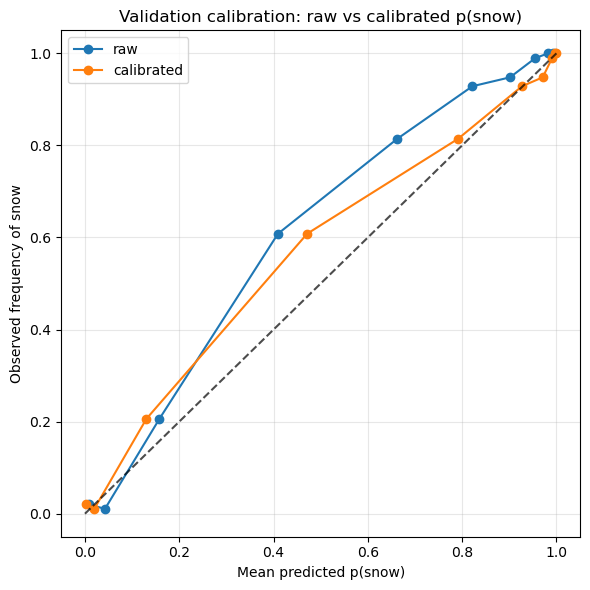

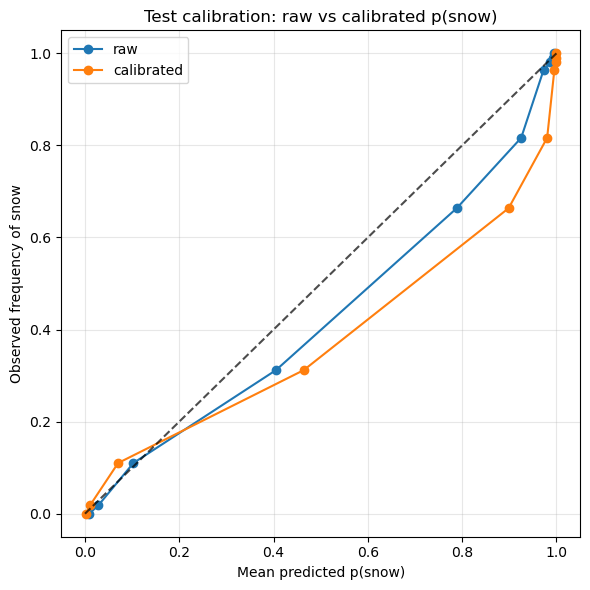

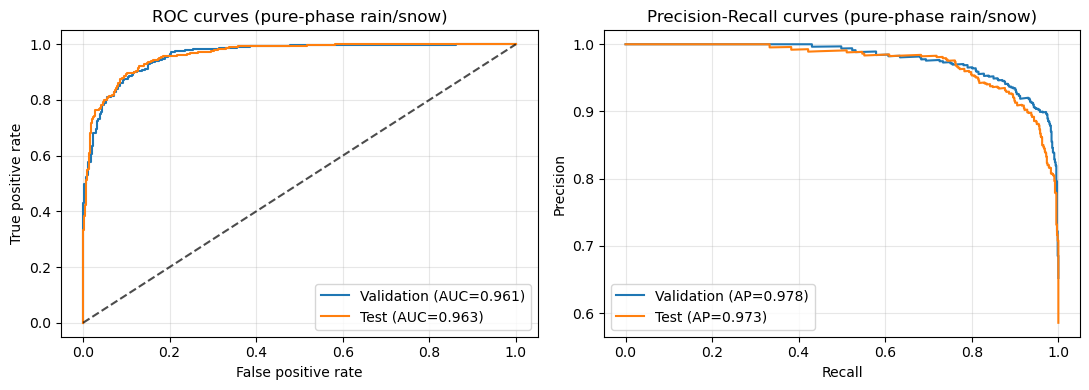

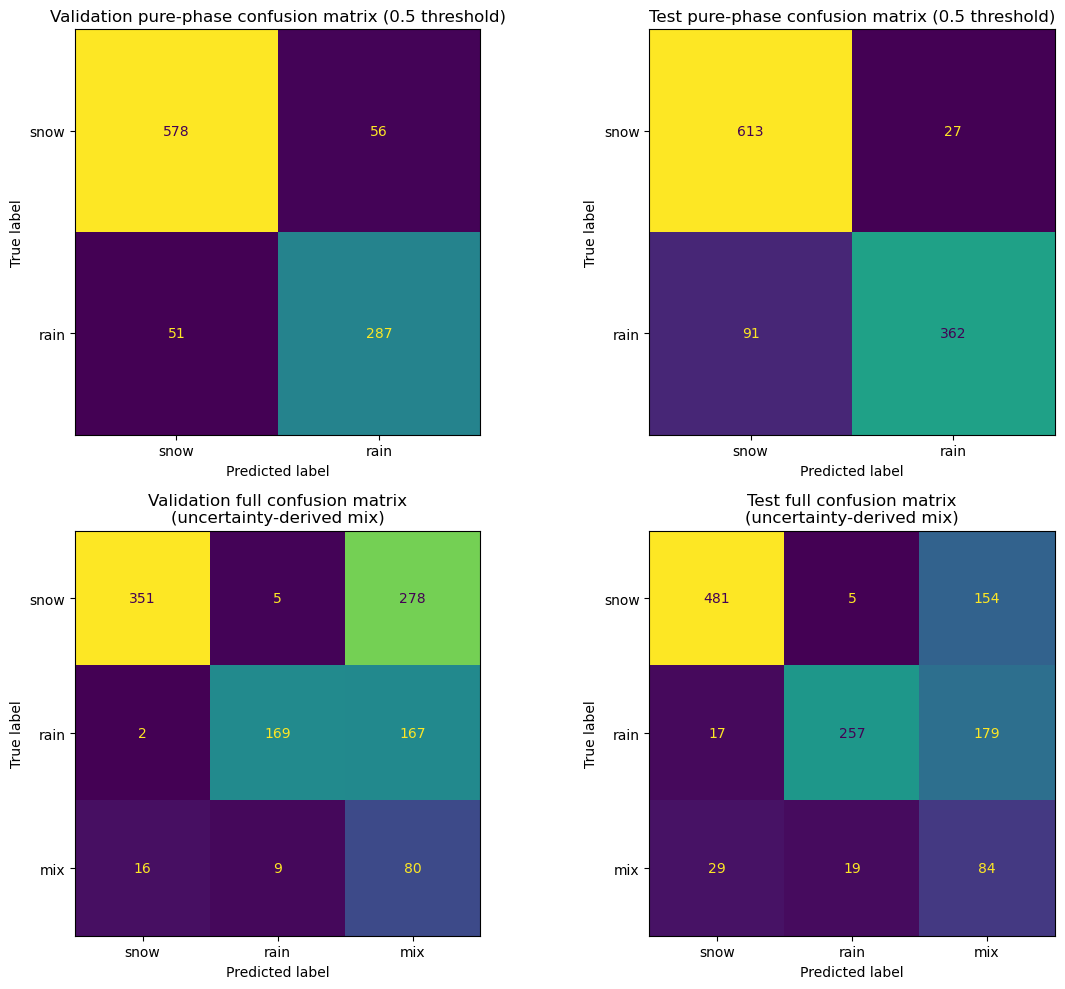

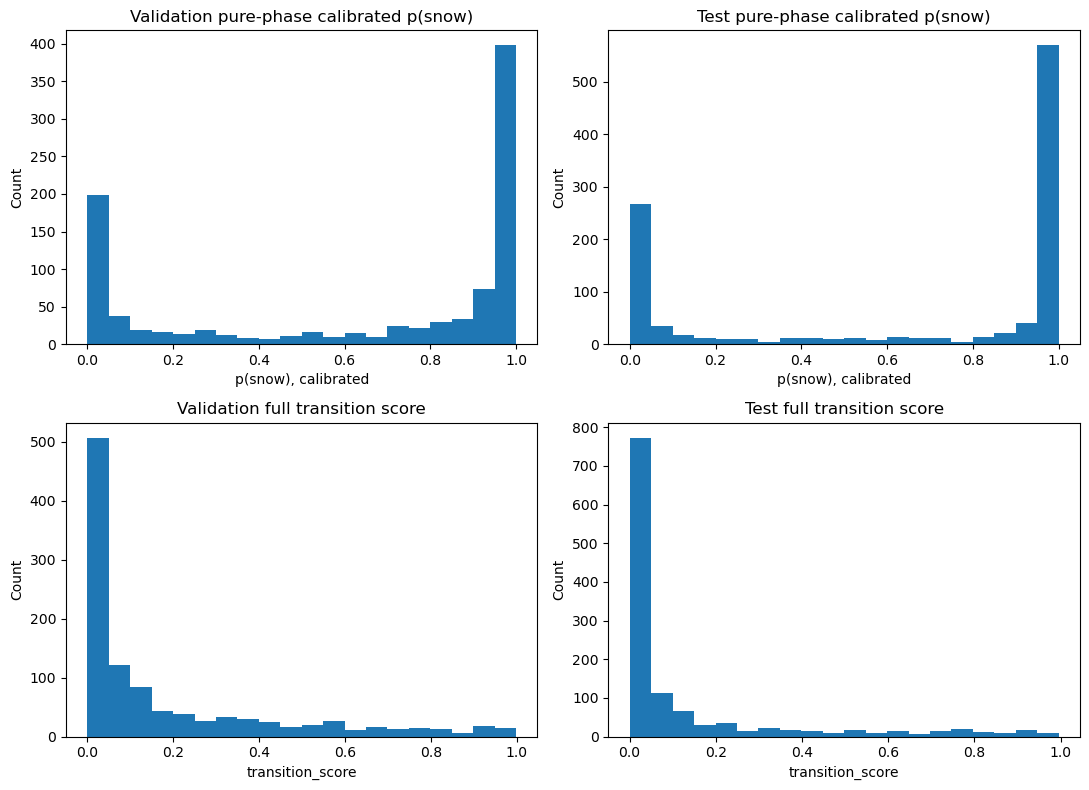

,conf_bin,n,accuracy,mean_confidence
0,"(0.499, 0.6]",44,0.363636,0.546768
1,"(0.6, 0.7]",45,0.622222,0.646042
2,"(0.7, 0.8]",78,0.641026,0.747328
3,"(0.8, 0.9]",97,0.855670,0.855003
4,"(0.9, 1.0]",708,0.971751,0.979607


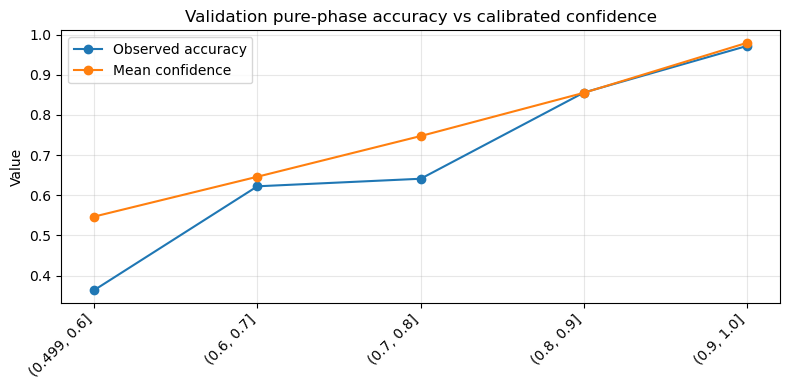

,conf_bin,n,accuracy,mean_confidence
0,"(0.499, 0.6]",39,0.615385,0.551765
1,"(0.6, 0.7]",41,0.560976,0.642313
2,"(0.7, 0.8]",35,0.714286,0.750744
3,"(0.8, 0.9]",65,0.615385,0.860100
4,"(0.9, 1.0]",913,0.945235,0.986368


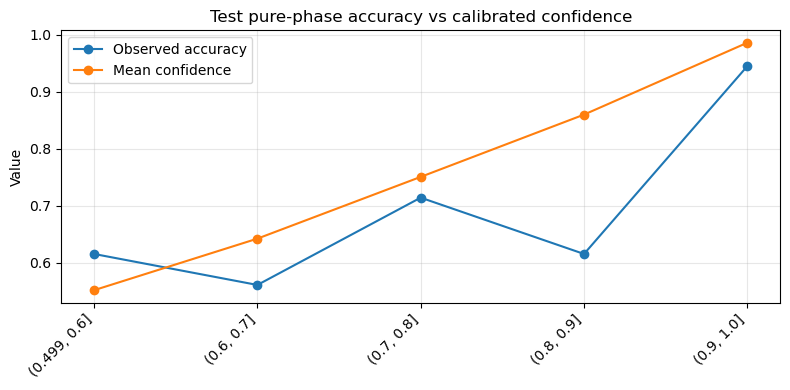

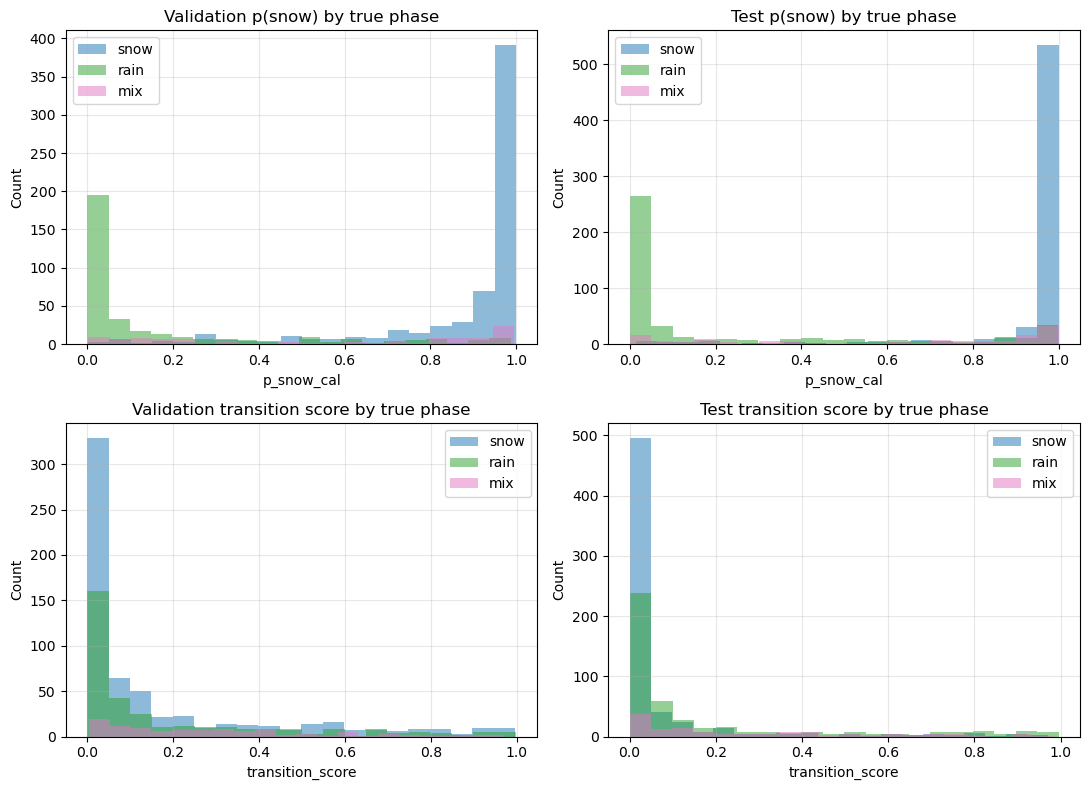


=== Validation | near_freezing_air_1C | uncertainty-derived 3-class report ===
              precision    recall  f1-score   support

        snow     0.9618    0.8235    0.8873       153
        rain     0.0000    0.0000    0.0000        15
         mix     0.1800    0.6429    0.2812        14

    accuracy                         0.7418       182
   macro avg     0.3806    0.4888    0.3895       182
weighted avg     0.8224    0.7418    0.7676       182


=== Validation | near_freezing_wet_1C | uncertainty-derived 3-class report ===
              precision    recall  f1-score   support

        snow     0.9459    0.1477    0.2555       237
        rain     1.0000    0.1646    0.2826       158
         mix     0.1544    0.9683    0.2664        63

    accuracy                         0.2664       458
   macro avg     0.7001    0.4268    0.2682       458
weighted avg     0.8557    0.2664    0.2663       458


=== Test | near_freezing_air_1C | uncertainty-derived 3-class report ===
    

In [24]:
# =============================================================================
# VALIDATION / TEST METRICS AND VISUALS
# =============================================================================

from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

PHASE_COLORS = {
    "snow": "#1f77b4",   # blue
    "rain": "#2ca02c",   # green
    "mix":  "#e377c2",   # pink
}


def summarize_binary_probability_metrics(y_true_bin, p_raw, p_cal, name: str) -> None:
    print(f"\n=== {name} | PURE-PHASE BINARY PROBABILITY METRICS ===")
    print(f"ROC AUC (raw/cal):         {roc_auc_score(y_true_bin, p_raw):.4f} / {roc_auc_score(y_true_bin, p_cal):.4f}")
    print(f"Average precision:        {average_precision_score(y_true_bin, p_cal):.4f}")
    print(f"Brier score (raw/cal):    {brier_score_loss(y_true_bin, p_raw):.4f} / {brier_score_loss(y_true_bin, p_cal):.4f}")
    print(f"Log loss (raw/cal):       {log_loss(y_true_bin, p_raw, labels=[0,1]):.4f} / {log_loss(y_true_bin, p_cal, labels=[0,1]):.4f}")


def summarize_binary_hard_metrics(y_true_phase, y_pred_phase, name: str) -> None:
    print(f"\n=== {name} | PURE-PHASE HARD BINARY METRICS (0.5 THRESHOLD) ===")
    print(f"Accuracy:          {accuracy_score(y_true_phase, y_pred_phase):.4f}")
    print(f"Balanced accuracy: {balanced_accuracy_score(y_true_phase, y_pred_phase):.4f}")
    print(f"Macro F1:          {f1_score(y_true_phase, y_pred_phase, average='macro'):.4f}")
    print(classification_report(
        y_true_phase,
        y_pred_phase,
        labels=[SNOW_CODE, RAIN_CODE],
        target_names=["snow", "rain"],
        digits=4,
        zero_division=0,
    ))


def summarize_uncertainty_phase_metrics(y_true_phase, y_pred_phase, name: str) -> None:
    print(f"\n=== {name} | UNCERTAINTY-DERIVED 3-CLASS METRICS ===")
    print(f"Accuracy:          {accuracy_score(y_true_phase, y_pred_phase):.4f}")
    print(f"Balanced accuracy: {balanced_accuracy_score(y_true_phase, y_pred_phase):.4f}")
    print(f"Macro F1:          {f1_score(y_true_phase, y_pred_phase, average='macro'):.4f}")
    print(classification_report(
        y_true_phase,
        y_pred_phase,
        labels=[SNOW_CODE, RAIN_CODE, MIX_CODE],
        target_names=FULL_CLASS_NAMES,
        digits=4,
        zero_division=0,
    ))


def summarize_mix_uncertainty_behavior(y_true_phase, y_pred_phase, dataset_name: str) -> None:
    y_true_phase = np.asarray(y_true_phase)
    y_pred_phase = np.asarray(y_pred_phase)

    true_mix = y_true_phase == MIX_CODE
    true_pure = np.isin(y_true_phase, [SNOW_CODE, RAIN_CODE])
    pred_mix = y_pred_phase == MIX_CODE
    pred_conf = y_pred_phase != MIX_CODE

    mix_capture = pred_mix[true_mix].mean() if true_mix.any() else np.nan
    pure_coverage = pred_conf[true_pure].mean() if true_pure.any() else np.nan
    pure_conf_acc = (y_pred_phase[true_pure & pred_conf] == y_true_phase[true_pure & pred_conf]).mean() if np.any(true_pure & pred_conf) else np.nan
    confident_fraction_all = pred_conf.mean()

    print(f"\n=== {dataset_name} | MIX / UNCERTAINTY BEHAVIOR ===")
    print(f"True-mix capture rate:            {mix_capture:.4f}")
    print(f"Pure-phase confident coverage:    {pure_coverage:.4f}")
    print(f"Pure-phase confident accuracy:    {pure_conf_acc:.4f}")
    print(f"Overall confident prediction frac:{confident_fraction_all:.4f}")


def plot_calibration_comparison(y_true_bin, p_raw, p_cal, title: str) -> None:
    frac_raw, mean_raw = calibration_curve(y_true_bin, p_raw, n_bins=10, strategy="quantile")
    frac_cal, mean_cal = calibration_curve(y_true_bin, p_cal, n_bins=10, strategy="quantile")

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(mean_raw, frac_raw, marker="o", label="raw")
    ax.plot(mean_cal, frac_cal, marker="o", label="calibrated")
    ax.plot([0, 1], [0, 1], "--", color="k", alpha=0.7)
    ax.set_xlabel("Mean predicted p(snow)")
    ax.set_ylabel("Observed frequency of snow")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_confidence_vs_accuracy(df_pred: pd.DataFrame, title: str) -> None:
    work = df_pred.copy()
    work["correct_binary05"] = (work["prediction_binary05"] == work["phase_full"]).astype(int)
    work["confidence"] = np.maximum(work["p_snow_cal"], work["p_rain_cal"])
    bins = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    work["conf_bin"] = pd.cut(work["confidence"], bins=bins, include_lowest=True)

    summary = (
        work.groupby("conf_bin", observed=False)
        .agg(
            n=("correct_binary05", "size"),
            accuracy=("correct_binary05", "mean"),
            mean_confidence=("confidence", "mean"),
        )
        .reset_index()
    )

    display(summary)

    plt.figure(figsize=(8, 4))
    plt.plot(summary["conf_bin"].astype(str), summary["accuracy"], marker="o", label="Observed accuracy")
    plt.plot(summary["conf_bin"].astype(str), summary["mean_confidence"], marker="o", label="Mean confidence")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Value")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------
# Validation diagnostics (probabilities + uncertainty product)
# ---------------------------------------------------------------------
y_val_bin = y_val.to_numpy()
y_test_bin = y_test.to_numpy()

summarize_binary_probability_metrics(y_val_bin, val_fit_prob_raw, val_fit_prob_cal, "Validation")
summarize_binary_probability_metrics(y_test_bin, test_fit_prob_raw, test_fit_prob_cal, "Test")

summarize_binary_hard_metrics(y_val_fit_phase, val_fit_pred_binary05, "Validation")
summarize_binary_hard_metrics(y_test_fit_phase, test_fit_pred_binary05, "Test")

summarize_uncertainty_phase_metrics(y_val_full_phase, val_full_pred_phase, "Validation")
summarize_uncertainty_phase_metrics(y_test_full_phase, test_full_pred_phase, "Test")

summarize_mix_uncertainty_behavior(y_val_full_phase, val_full_pred_phase, "Validation")
summarize_mix_uncertainty_behavior(y_test_full_phase, test_full_pred_phase, "Test")

# ---------------------------------------------------------------------
# Calibration curves: raw vs calibrated on pure-phase subsets
# ---------------------------------------------------------------------
plot_calibration_comparison(
    y_val_bin,
    val_fit_prob_raw,
    val_fit_prob_cal,
    title="Validation calibration: raw vs calibrated p(snow)",
)

plot_calibration_comparison(
    y_test_bin,
    test_fit_prob_raw,
    test_fit_prob_cal,
    title="Test calibration: raw vs calibrated p(snow)",
)

# ---------------------------------------------------------------------
# ROC / PR curves on pure-phase subsets
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for y_true_bin, p_cal, label in [
    (y_val_bin, val_fit_prob_cal, "Validation"),
    (y_test_bin, test_fit_prob_cal, "Test"),
]:
    fpr, tpr, _ = roc_curve(y_true_bin, p_cal)
    prec, rec, _ = precision_recall_curve(y_true_bin, p_cal)
    axes[0].plot(fpr, tpr, label=f"{label} (AUC={roc_auc_score(y_true_bin, p_cal):.3f})")
    axes[1].plot(rec, prec, label=f"{label} (AP={average_precision_score(y_true_bin, p_cal):.3f})")

axes[0].plot([0, 1], [0, 1], "--", color="k", alpha=0.7)
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curves (pure-phase rain/snow)")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curves (pure-phase rain/snow)")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# Confusion matrices
# ---------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

cm_val_bin = confusion_matrix(y_val_fit_phase, val_fit_pred_binary05, labels=[SNOW_CODE, RAIN_CODE])
ConfusionMatrixDisplay(cm_val_bin, display_labels=["snow", "rain"]).plot(ax=axes[0, 0], colorbar=False)
axes[0, 0].set_title("Validation pure-phase confusion matrix (0.5 threshold)")

cm_test_bin = confusion_matrix(y_test_fit_phase, test_fit_pred_binary05, labels=[SNOW_CODE, RAIN_CODE])
ConfusionMatrixDisplay(cm_test_bin, display_labels=["snow", "rain"]).plot(ax=axes[0, 1], colorbar=False)
axes[0, 1].set_title("Test pure-phase confusion matrix (0.5 threshold)")

cm_val_unc = confusion_matrix(y_val_full_phase, val_full_pred_phase, labels=[SNOW_CODE, RAIN_CODE, MIX_CODE])
ConfusionMatrixDisplay(cm_val_unc, display_labels=FULL_CLASS_NAMES).plot(ax=axes[1, 0], colorbar=False)
axes[1, 0].set_title("Validation full confusion matrix\n(uncertainty-derived mix)")

cm_test_unc = confusion_matrix(y_test_full_phase, test_full_pred_phase, labels=[SNOW_CODE, RAIN_CODE, MIX_CODE])
ConfusionMatrixDisplay(cm_test_unc, display_labels=FULL_CLASS_NAMES).plot(ax=axes[1, 1], colorbar=False)
axes[1, 1].set_title("Test full confusion matrix\n(uncertainty-derived mix)")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# Probability / uncertainty distributions
# ---------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].hist(df_val_fit["p_snow_cal"], bins=20)
axes[0, 0].set_title("Validation pure-phase calibrated p(snow)")
axes[0, 0].set_xlabel("p(snow), calibrated")
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(df_test_fit["p_snow_cal"], bins=20)
axes[0, 1].set_title("Test pure-phase calibrated p(snow)")
axes[0, 1].set_xlabel("p(snow), calibrated")
axes[0, 1].set_ylabel("Count")

axes[1, 0].hist(df_val_full["transition_score"], bins=20)
axes[1, 0].set_title("Validation full transition score")
axes[1, 0].set_xlabel("transition_score")
axes[1, 0].set_ylabel("Count")

axes[1, 1].hist(df_test_full["transition_score"], bins=20)
axes[1, 1].set_title("Test full transition score")
axes[1, 1].set_xlabel("transition_score")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# Confidence vs accuracy on pure-phase subsets
# ---------------------------------------------------------------------
plot_confidence_vs_accuracy(df_val_fit, "Validation pure-phase accuracy vs calibrated confidence")
plot_confidence_vs_accuracy(df_test_fit, "Test pure-phase accuracy vs calibrated confidence")

# ---------------------------------------------------------------------
# Probability and transition score by true phase (full sets)
# ---------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, df_, title, col in [
    (axes[0, 0], df_val_full, "Validation p(snow) by true phase", "p_snow_cal"),
    (axes[0, 1], df_test_full, "Test p(snow) by true phase", "p_snow_cal"),
    (axes[1, 0], df_val_full, "Validation transition score by true phase", "transition_score"),
    (axes[1, 1], df_test_full, "Test transition score by true phase", "transition_score"),
]:
    for code, cname in zip([SNOW_CODE, RAIN_CODE, MIX_CODE], FULL_CLASS_NAMES):
        vals = df_.loc[df_["phase_full"] == code, col]
        ax.hist(vals, bins=20, alpha=0.5, label=cname, color=PHASE_COLORS[cname])
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# Near-freezing subset summaries for the full uncertainty-derived product
# ---------------------------------------------------------------------
for name, df_ in [("Validation", df_val_full), ("Test", df_test_full)]:
    for flag in ["near_freezing_air_1C", "near_freezing_wet_1C"]:
        sub = df_[df_[flag]].copy()
        if sub.empty:
            continue
        print(f"\n=== {name} | {flag} | uncertainty-derived 3-class report ===")
        print(classification_report(
            sub["phase_full"],
            sub["prediction_phase_uncertainty"],
            labels=[SNOW_CODE, RAIN_CODE, MIX_CODE],
            target_names=FULL_CLASS_NAMES,
            digits=4,
            zero_division=0,
        ))
